# Notebook Tema 5 VA, Master IA UMU, curso 2025/26
# _Comparación entre características clásicas y aprendidas usando CNNs_

In [ ]:
!date

Thu Nov 13 09:23:24 AM UTC 2025


## Imports necesarios

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import skimage
import math
import tensorflow as tf
from tensorflow import keras
from keras import layers, initializers
from pathlib import Path
from skimage import io
from skimage import color
from skimage.transform import rescale
from skimage.filters import gabor_kernel
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## Descarga del dataset de imágenes

Utilizaremos el dataset ALOT ("Amsterdam Library of textures"), que puede encontrarse en este enlace: [https://aloi.science.uva.nl/public_alot/](https://aloi.science.uva.nl/public_alot/).

In [ ]:
# wget http://movideep.inf.um.es/public/alot9classes.tgz -O alot9classes.tgz --user public --password public
# LINK ALTERNATIVO:
! wget https://univmurcia-my.sharepoint.com/:u:/g/personal/pedroe_um_es/EdMsASIjwBFLoeCDNysGRCQBaMeC9ZgsftwolQyEuJArYw?download=1 -O alot9classes.tgz
# Nota: Con el comando
#        ! wget http://movideep.inf.um.es/public/alot250classes.tgz -O alot250classes.tgz --user public --password public
#       se puede descargar el dataset completo (250 tipos de texturas), para jugar, si así se desea, con otras texturas
#       diferentes a las usadas en este notebook.

--2025-11-13 09:23:42--  https://univmurcia-my.sharepoint.com/:u:/g/personal/pedroe_um_es/EdMsASIjwBFLoeCDNysGRCQBaMeC9ZgsftwolQyEuJArYw?download=1
Resolving univmurcia-my.sharepoint.com (univmurcia-my.sharepoint.com)... 13.107.136.10, 13.107.138.10, 2620:1ec:8f8::10, ...
Connecting to univmurcia-my.sharepoint.com (univmurcia-my.sharepoint.com)|13.107.136.10|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/pedroe_um_es/Documents/00%20-%20NotebookFiles-VA-MIA/Notebook_Textures/alot9classes.tgz?ga=1 [following]
--2025-11-13 09:23:43--  https://univmurcia-my.sharepoint.com/personal/pedroe_um_es/Documents/00%20-%20NotebookFiles-VA-MIA/Notebook_Textures/alot9classes.tgz?ga=1
Reusing existing connection to univmurcia-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 147318388 (140M) [application/x-compressed]
Saving to: ‘alot9classes.tgz’

alot9classes.tgz    100%[===================>] 140.49M  4.65MB/s    in 24s     

2025-

En nuestro caso usaremos sólo las nueve primeras clases, para cada una de las cuales se dispone de 100 imágenes (en su resolución más pequeña):

In [ ]:
! file alot9classes.tgz

alot9classes.tgz: gzip compressed data, from Unix, original size modulo 2^32 148070400


In [ ]:
! rm -rf alot9classes
! tar xzvf alot9classes.tgz | sort > output.txt
! head -n5 output.txt && echo "..." `grep ".png" output.txt | wc -l` "files in total ..."  && tail -n5 output.txt

alot9classes/
alot9classes/1/
alot9classes/1/1_c1i.png
alot9classes/1/1_c1l1.png
alot9classes/1/1_c1l1r120.png
... 900 files in total ...
alot9classes/9/9_c4l5r60.png
alot9classes/9/9_c4l8.png
alot9classes/9/9_c4l8r120.png
alot9classes/9/9_c4l8r180.png
alot9classes/9/9_c4l8r60.png


In [ ]:
!file alot9classes/1/1_c1i.png

alot9classes/1/1_c1i.png: PNG image data, 384 x 256, 8-bit/color RGB, non-interlaced


In [ ]:
%%time

def read_images(pathname, gray=False):
  path = Path(pathname)
  labels = sorted([l.name for l in path.iterdir()])
  imgs = []
  for classpath in [path / l for l in labels]:
    imgsclass = [io.imread(filepath) for filepath in sorted([p for p in classpath.iterdir()])]
    # Aún tratándose de las imágenes más pequeñas, las escalamos a un tamaño 0.5 del original,
    # para hacer el dataset más tratable computacionalmente:
    imgs.append([rescale(skimage.img_as_float32(img), 0.5, anti_aliasing=True, channel_axis=2) for img in imgsclass])

  # No todas las imágenes tienen exactamente la misma forma -> cogemos un parche centrado y con
  # tamaño igual al de la imagen más pequeña de todas las de entrada:
  allshapes = np.array([np.array(img.shape) for imgsclass in imgs for img in imgsclass])
  H, W, C = np.min(allshapes,axis=0)
  for i, imgsclass in enumerate(imgs):
    for j, img in enumerate(imgsclass):
      Hi, Wi, Ci = img.shape
      imgs[i][j] = np.copy(img[(Hi-H)//2:H+(Hi-H)//2:,(Wi-W)//2:W+(Wi-W)//2:,:])
  allshapes = np.array([np.array(img.shape) for imgsclass in imgs for img in imgsclass])
  assert True == np.all(allshapes == np.array([H,W,C])), f"Some image could not be cut to shape {(H,w,C)}"

  NC = len(imgs)                                 # Número de clases.
  NICs = [len(imgsclass) for imgsclass in imgs]  # Lista de número de imágenes por clase.
  NIs = sum(NICs)                                # Número total de imágenes.
  return imgs, labels, H, W, C, NC, NICs, NIs

imgs, labels, H, W, C, NC, NICs, NIs = read_images("alot9classes")
print(f" Número total de clases: {NC}\n"
      f" Número total de imágenes: {NIs}\n"
      f" Número de imágenes por cada clase: ({[ (i,l+'/',ncs) for (i,l,ncs) in zip(range(len(labels)),labels,NICs)]})\n"
      f" Todas las imágenes escaladas y recortadas a tamaño: {imgs[0][0].shape} (H, W, C = {H}, {W}, {C})\n"
      f" Tipo de datos: {imgs[0][0].dtype}\n"
      f" Rango: [{np.min([np.min(img) for imgsclass in imgs for img in imgsclass])},{np.max([np.max(img) for imgsclass in imgs for img in imgsclass])}]")

 Número total de clases: 9
 Número total de imágenes: 900
 Número de imágenes por cada clase: ([(0, '1/', 100), (1, '2/', 100), (2, '3/', 100), (3, '4/', 100), (4, '5/', 100), (5, '6/', 100), (6, '7/', 100), (7, '8/', 100), (8, '9/', 100)])
 Todas las imágenes escaladas y recortadas a tamaño: (82, 192, 3) (H, W, C = 82, 192, 3)
 Tipo de datos: float32
 Rango: [0.0,0.9960784912109375]
CPU times: user 9.96 s, sys: 267 ms, total: 10.2 s
Wall time: 10.3 s


Dibujamos las primeras 10 imágenes por cada clase (una fila por clase):


CPU times: user 4.75 s, sys: 25.2 ms, total: 4.78 s
Wall time: 4.82 s


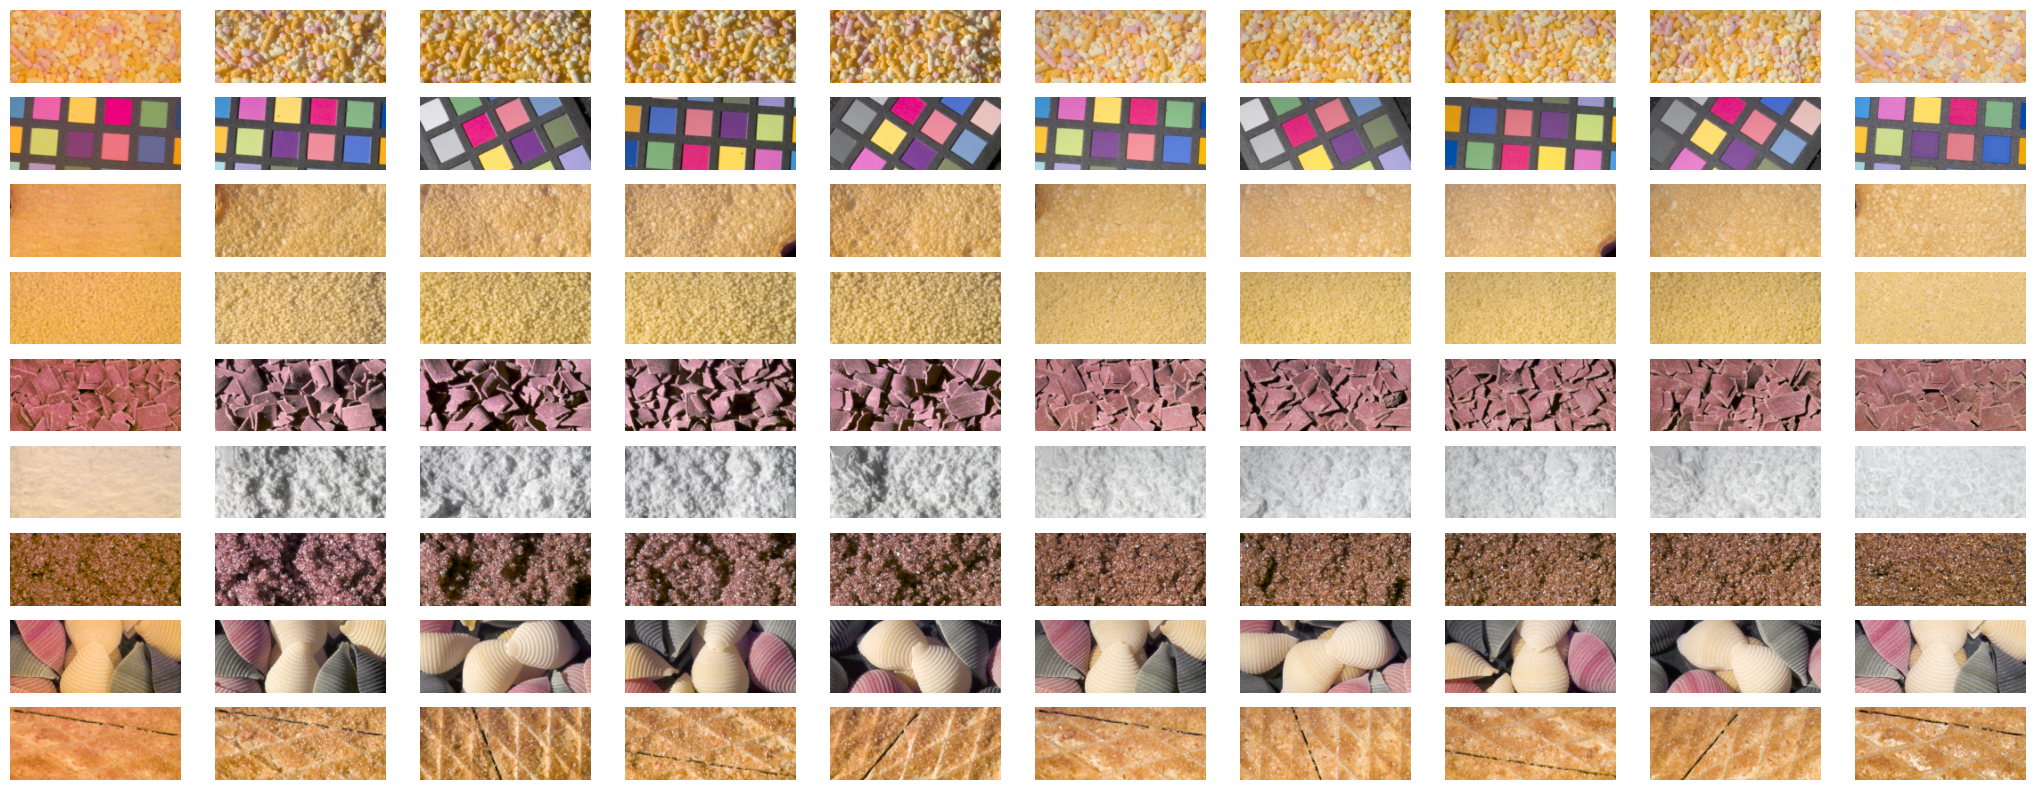

In [ ]:
%%time

def plot_imgs(imgs, n_imgs_per_class=5, title=""):
  assert n_imgs_per_class>=2, "n_imgs_per_class debe ser >=2 en función plot_imgs"
  rows, cols = imgs[0][0].shape[:2]
  aspect_ratio = (rows*NC) / (cols*n_imgs_per_class)
  fig, axs, = plt.subplots(NC, n_imgs_per_class, figsize=(10.0/aspect_ratio, 10.0),sharex=True, sharey=True)
  for r in range(NC):
    for c in range(n_imgs_per_class):
      axs[r,c].imshow(imgs[r][c], cmap="gray")
      axs[r,c].axis("off")
  if(title != ""):
    fig.suptitle(title, fontsize=20, y=0.925)

plot_imgs(imgs, 10)

## Generación de parches de entrenamiento/test/validación a partir de las imágenes

Usaremos los siguientes parámetros para generar el dataset de parches:

In [ ]:
TS                 = 40         # Tamaño de los parches (tiles).
OVERLAP            = True       # Si los parches serán con solapamiento.
TILE_STRIDE        = 20         # Stride utilizado para obtener los parches (en caso de que OVERLAP sea True).
NIS_TEST           = 10         # Las últimas NIS_TEST + NIS_VAL imágenes de cada clase no se verán
NIS_VAL            = 10         # durante el entrenamiento (10 imágenes para test y 10 para validación).
MAX_SAMPLES        = 30000      # Limitamos el número de parches por experimento.

In [ ]:
def split_img_in_tiles(img, tile_size, stride, overlap):
  if not overlap:
    # Parches sin solapamiento (ojo, salen bastante menos parches por imagen):
    return np.array([
        np.array(img[x:x+tile_size,y:y+tile_size])
        for x in range(0,img.shape[0]-tile_size+1,tile_size)
        for y in range(0,img.shape[1]-tile_size+1,tile_size)])
  else:
    # Parches con solapamiento (stride=TILE_STRIDE píxeles; genera muchos más parches por cada imagen):
    return np.array([
        np.array(img[x:x+tile_size,y:y+tile_size])
        for x in range(0,img.shape[0]-tile_size+1,stride)
        for y in range(0,img.shape[1]-tile_size+1,stride)
      ])

def generate_tiles_sets(overlap = False):
  tiles_train, tiles_test, tiles_val = [], [], []
  labels_train, labels_test, labels_val = [], [], []
  # c recorre las NC clases:
  for c in range(len(imgs)):
    # i recorre las imágenes de cada clase; un bucle para crear el conjunto de
    # train, otro para crear el de test, y un tercero para el de validación:
    for i in range(0,NICs[c]-NIS_TEST-NIS_VAL):
      for tile in split_img_in_tiles(imgs[c][i], TS, stride=TILE_STRIDE, overlap=overlap):
        tiles_train.append(tile)
        labels_train.append(c)
    for i in range(NICs[c]-NIS_TEST-NIS_VAL,NICs[c]-NIS_VAL):
      for tile in split_img_in_tiles(imgs[c][i], TS, stride=TILE_STRIDE, overlap=overlap):
        tiles_test.append(tile)
        labels_test.append(c)
    for i in range(NICs[c]-NIS_VAL,NICs[c]):
      for tile in split_img_in_tiles(imgs[c][i], TS, stride=TILE_STRIDE, overlap=overlap):
        tiles_val.append(tile)
        labels_val.append(c)
  tiles_train, tiles_test, tiles_val = np.array(tiles_train), np.array(tiles_test), np.array(tiles_val)
  labels_train, labels_test, labels_val = np.array(labels_train), np.array(labels_test), np.array(labels_val)
  return tiles_train, tiles_test, tiles_val, labels_train, labels_test, labels_val

tiles_train, tiles_test, tiles_val, labels_train, labels_test, labels_val = generate_tiles_sets(OVERLAP)
print(f" Parches por cada imagen: {len(split_img_in_tiles(imgs[0][0], TS, stride=TILE_STRIDE, overlap=OVERLAP))}\n"
      f" Número total de imágenes empleadas para training: {NIs-NC*NIS_TEST-NC*NIS_VAL}\n"
      f" Número total de imágenes empleadas para test: {NC*NIS_TEST}\n"
      f" Número total de imágenes empleadas para validación: {NC*NIS_VAL}\n"
      f" Número total de parches usados para training: {len(tiles_train)}\n"
      f" Número total de parches usados para test: {len(tiles_test)}\n"
      f" Número total de parches usados para validación: {len(tiles_val)}\n"
      f" Número total de parches: {len(tiles_train)+len(tiles_test)+len(tiles_val)}\n"
      f" Dimensiones de cada parche: {tiles_train[0].shape}\n"
      f" Tipo de dato: {tiles_train[0].dtype}\n"
      f" Rango del primer parche de entrenamiento: [{np.min(tiles_train[0])},{np.max(tiles_train[0])}]")

 Parches por cada imagen: 24
 Número total de imágenes empleadas para training: 720
 Número total de imágenes empleadas para test: 90
 Número total de imágenes empleadas para validación: 90
 Número total de parches usados para training: 17280
 Número total de parches usados para test: 2160
 Número total de parches usados para validación: 2160
 Número total de parches: 21600
 Dimensiones de cada parche: (40, 40, 3)
 Tipo de dato: float32
 Rango del primer parche de entrenamiento: [0.06550892442464828,0.9764320254325867]


Dibujamos los veinte primeros parches por cada clase (una fila por clase), para los conjuntos de training (y, si se desea, también de test y de validación):

CPU times: user 26.1 s, sys: 53.4 ms, total: 26.2 s
Wall time: 26.3 s


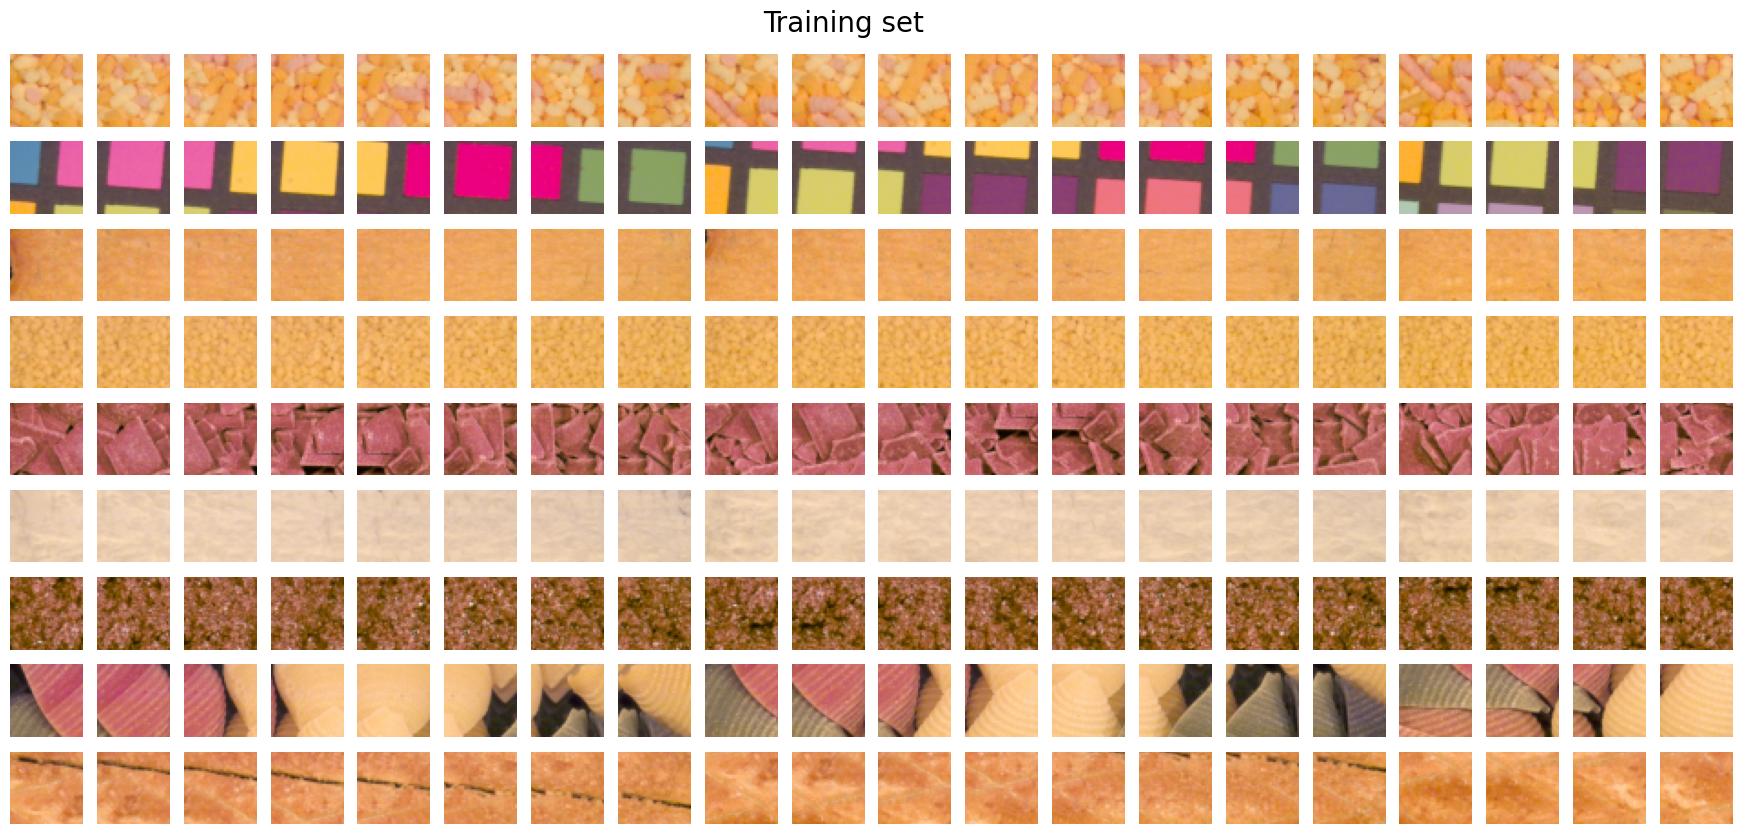

In [ ]:
%%time

plot_imgs(tiles_train.reshape(NC, -1, TS, TS, C), 20, title="Training set")
# plot_imgs(tiles_test.reshape(NC, -1, TS, TS, C), 20, title="Test set")
# plot_imgs(tiles_val.reshape(NC, -1, TS, TS, C), 20, title="Validation set")

# Conjunto prefijado (_hand engineered_) de filtros de Gabor

Generamos un conjunto de 40 filtros de Gabor (8 orientaciones x 5 combinaciones diferentes de sigmas, frecuencias y fases; explicación de la función de generación y sus parámetros principales [aquí](https://www.baeldung.com/cs/ml-gabor-filters)), formando máscaras de tamaño 17x17:

In [ ]:
GABOR_ORIENTATIONS = 8
GABOR_SIZE         = 17
GABOR_PARMS        = [(1.5, GABOR_SIZE, 0), (1.5, GABOR_SIZE, np.pi/2), (2.5, GABOR_SIZE/2, 0), (3.5, GABOR_SIZE/3, np.pi/2), (5.0, GABOR_SIZE/1.75, np.pi/2)]
NKGABOR            = GABOR_ORIENTATIONS * len(GABOR_PARMS)   # Número total de filtros de Gabor (escala de grises)
NKGABORRGB         = 3*NKGABOR                               # Número total de filtros de Gabor (RGB)

Número total de filtros (kernels) de Gabor: 40
Forma del tensor de filtros de GABOR sobre imagen de grises: (17, 17, 1, 40)
Forma del tensor de filtros de GABOR sobre imagen RGB: (17, 17, 3, 120)


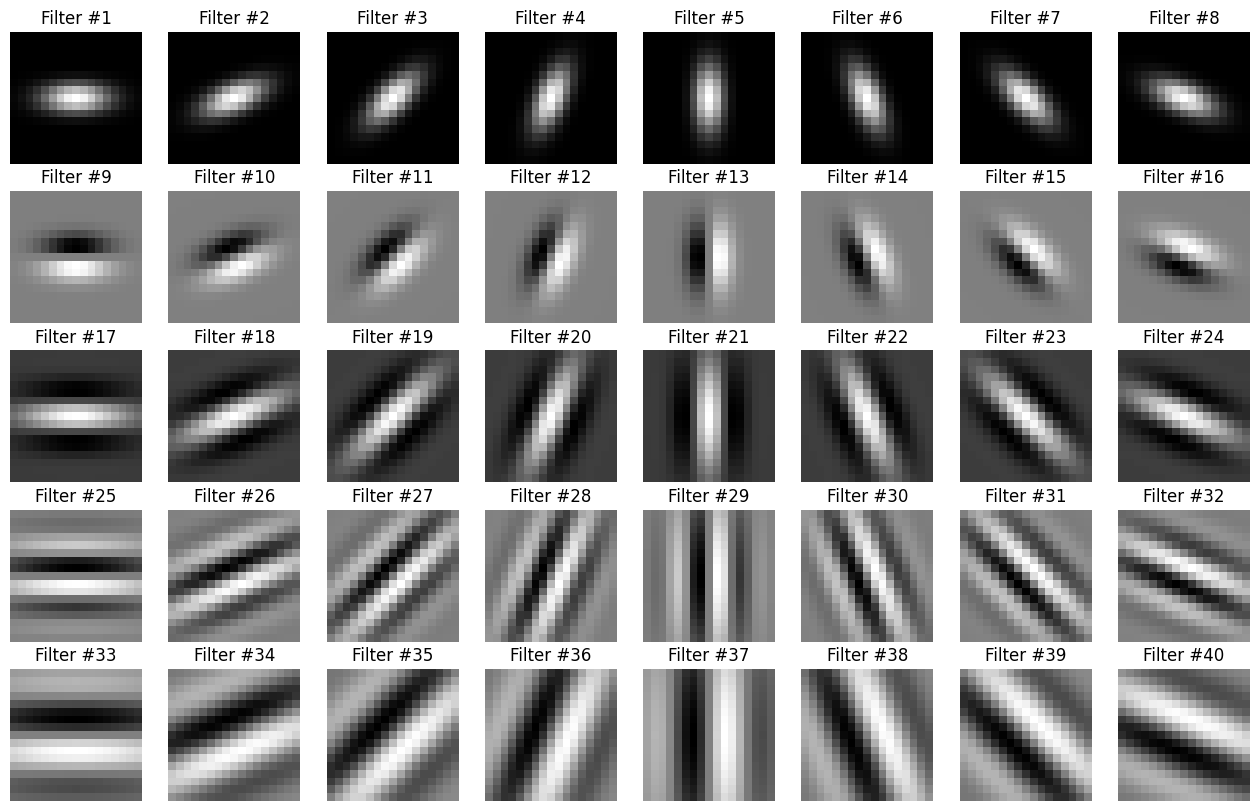

In [ ]:
def gen_gabor_tensor():
  kernels = []
  for sigma, lambd, psi in GABOR_PARMS:
    for theta in range(GABOR_ORIENTATIONS):
        kernel = cv2.getGaborKernel((GABOR_SIZE,GABOR_SIZE), sigma=sigma, theta=theta / float(GABOR_ORIENTATIONS) * np.pi, lambd=lambd , gamma=0.5, psi=psi) #, ktype=cv2.CV_32F)
        kernels.append(kernel)
  kerneltensor = np.array(kernels)
  kerneltensorgray = np.moveaxis(kerneltensor, [0, 1, 2], [2, 1, 0])[:,:,np.newaxis,:]
  rows,cols,chans,nfs = kerneltensorgray.shape
  kerneltensorrgb = np.zeros((rows,cols,3,nfs*3))
  for i in range(nfs):
    for j in range(3):
      kerneltensorrgb[:,:,j,3*i+j] = kerneltensorgray[:,:,0,i]
  return kerneltensorgray, kerneltensorrgb

def plot_filters(kerneltensor):
  fig, axs = plt.subplots(NKGABOR//GABOR_ORIENTATIONS,GABOR_ORIENTATIONS, figsize=(2.0*GABOR_ORIENTATIONS,2.0*NKGABOR//GABOR_ORIENTATIONS))
  for i in range(NKGABOR):
    axs[i//GABOR_ORIENTATIONS,i%GABOR_ORIENTATIONS].imshow(kerneltensor[:,:,0,i], cmap="gray")
    axs[i//GABOR_ORIENTATIONS,i%GABOR_ORIENTATIONS].axis("off")
    axs[i//GABOR_ORIENTATIONS,i%GABOR_ORIENTATIONS].set_title(f"Filter #{i+1}")

kerneltensorgray, kerneltensorrgb = gen_gabor_tensor()
assert NKGABOR == kerneltensorgray.shape[-1]
plot_filters(kerneltensorgray)
print(f"Número total de filtros (kernels) de Gabor: {NKGABOR}\n"
      f"Forma del tensor de filtros de GABOR sobre imagen de grises: {kerneltensorgray.shape}\n"
      f"Forma del tensor de filtros de GABOR sobre imagen RGB: {kerneltensorrgb.shape}")

# Cómputo de vectores de características

## Modelo Keras para cómputo de vectores de características

Definimos un modelo con 4 capas de Keras para generar, a partir de cada parche de entrada, un vector de salida de tamaño 1960 (para parches de entrada tipo gray) o 5880 (para parches de tipo rgb). Lo haremos con un modelo de Keras porque es mucho más rápido computar todos los vectores para un conjunto grande de parches de una sola vez, usando un _batch_ con todos ellos. Computaremos así los vectores de características Gabor gray y Gabor RGB de una sola vez (_batch_) para cada conjunto (training, test, validación) de parches de entrada.

Obsérvese que en este caso, aunque usemos un modelo de Keras, fijaremos todos los pesos necesarios a priori (es decir, no será necesario realizar ningún entrenamiento sobre ellos; son características (_features_) de tipo _hand_engineered_):

In [ ]:
def modelTileToGaborVector(gray = True):
  if gray:
    layerGaborGray = layers.Conv2D(kerneltensorgray.shape[-1], kernel_size=(GABOR_SIZE,GABOR_SIZE), strides=(1,1), padding='valid', use_bias=False, name="GaborGray")
    layerGaborGray.build((1,TS,TS,1))
    layerGaborGray.set_weights([kerneltensorgray])
  else:
    layerGaborRGB  = layers.Conv2D(kerneltensorrgb.shape[-1], kernel_size=(GABOR_SIZE,GABOR_SIZE), strides=(1,1), padding='valid', use_bias=False, name="GaborRGB")
    layerGaborRGB.build((1,TS,TS,3))
    layerGaborRGB.set_weights([kerneltensorrgb])
  return keras.Sequential([
        keras.Input(shape=(TS, TS, 1 if gray else 3), name="Input"),  # Input shape (None,40,40,3) para RGB, (None,40,40,1) para gray.
        layerGaborGray if gray else layerGaborRGB,                    # Shape (None,24,24,120) (el filtro 17x17, padding "valid", se "come" 8 píxeles por cada lado; y hay 120 filtros).
        layers.AveragePooling2D(pool_size=(2, 2), strides=(1,1),      # Shape (None,23,23,120) (el filtro average 2x2, stride 1x1, se "come" un píxel).
                                padding="valid", name="Average"),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(3,3),          # Shape (None,7,7,120) (el filtro maxpool 3x3, stride 3x3, hace la división entera 23/3x23/3 = 7x7).
                            padding="valid", name="MaxPool"),
        layers.Flatten(name="Flatten"),                               # Shape (None, 5880) (el efecto del flatten, 7x7x120=5880).
      ], name="modelGaborGray" if gray else "modelGaborRGB")

# Creamos un modelo para entrada de parches de gris, y otro para parches RGB
modelGaborGray = modelTileToGaborVector(gray = True)
modelGaborGray.summary()
print("\n\n")
modelGaborRGB = modelTileToGaborVector(gray = False)
modelGaborRGB.summary()

# Probamos el modelo con un parche de entrada, para comprobar la forma del tensor de
# salida. Nótese que para usar un modelo hay que pasarle un *batch* de ejemplos,
# aunque, como en este caso, sólo haya un ejemplo con el que llamar al modelo.
# Por ejemplo, para un parche RGB, la salida es un vector de 5880 componentes:
output = modelGaborRGB(np.array([tiles_train[0]]))
print(output.shape)
# Nota: El valor exacto de 5880 se puede deducir de las sucesivas transformaciones
#       sobre el tile de entrada que va haciendo cada capa del modelo:
assert output.shape[-1] == NKGABORRGB*(((TS-2*(GABOR_SIZE//2))-1)//3)**2

Model: "modelGaborGray"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ GaborGray (Conv2D)              │ (None, 24, 24, 40)     │        11,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Average (AveragePooling2D)      │ (None, 23, 23, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool (MaxPooling2D)          │ (None, 7, 7, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 1960)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,560 (45.16 KB)

 Trainable params: 11,560 (45.16 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ GaborRGB (Conv2D)               │ (None, 24, 24, 120)    │       104,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Average (AveragePooling2D)      │ (None, 23, 23, 120)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool (MaxPooling2D)          │ (None, 7, 7, 120)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 5880)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,040 (406.41 KB)

 Trainable params: 104,040 (406.41 KB)

 Non-trainable params: 0 (0.00 B)

(1, 5880)


He aquí la imagen de la arquitectura de procesamiento de la red, en forma de "flujo de tensores" (de ahí, p.e., el nombre de TensorFlow):
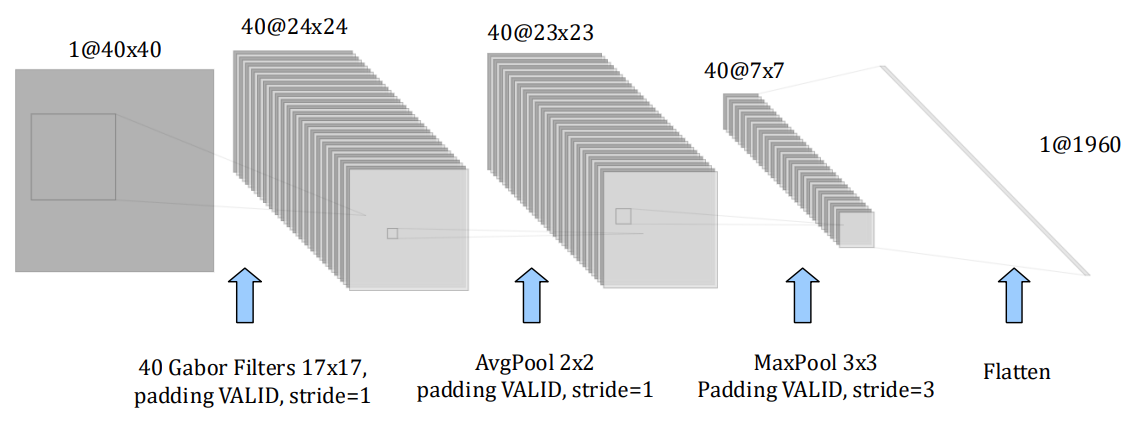

## Cómputo de datasets de características

Computamos ahora, para cada tile de entrada, cuatro vectores de características diferentes (formando así cuatro datasets diferentes en los que hacer pruebas de aprendizaje):
* Vector (parche aplanado) de niveles de gris.
* Vector (parche aplanado) RGB.
* Vector con características procesadas a partir de los filtros de Gabor para niveles de gris (salida del modelo `modelGaborGray`).
* Vector con características procesadas a partir de los filtros de Gabor para RGB (salida del modelo y `modelGaborRGB`).

In [ ]:
%%time

def features(tiles, feat):
  if feat == "gray":
    return np.mean(tiles,axis=3).reshape(len(tiles),-1)
  elif feat == "rgb":
    return tiles.reshape(len(tiles),-1)
  elif feat == "gabor_gray":
    return modelGaborGray(np.mean(tiles,axis=3)).numpy()
  elif feat == "gabor_rgb":
    return modelGaborRGB(tiles).numpy()
  else:
    raise(ValueError(f"Incorrect extractor={extractor} parameter in features(...) function. Valid values: gray / rgb / gabor_gray / gabor_rgb"))

def compute_features_datasets(feat_types):
  X_train, X_test, X_val = {}, {}, {}
  for feat_type in feat_types:
    X_train[feat_type] = features(tiles_train, feat_type)
    X_test[feat_type] = features(tiles_test, feat_type)
    X_val[feat_type] = features(tiles_val, feat_type)
  return X_train, X_test, X_val

feat_types = ["gray", "rgb", "gabor_gray", "gabor_rgb"]
X_train, X_test, X_val = compute_features_datasets(feat_types)
print(f'Vectores gray:       train {X_train["gray"].shape}, test {X_test["gray"].shape}, val {X_val["gray"].shape}\n'
      f'Vectores RGB:        train {X_train["rgb"].shape}, test {X_test["rgb"].shape}, val {X_val["rgb"].shape}\n'
      f'Vectores Gabor gray: train {X_train["gabor_gray"].shape}, test {X_test["gabor_gray"].shape}, val {X_val["gabor_gray"].shape}\n'
      f'Vectores Gabor RGB:  train {X_train["gabor_rgb"].shape}, test {X_test["gabor_rgb"].shape}, val {X_val["gabor_rgb"].shape}')

Vectores gray:       train (17280, 1600), test (2160, 1600), val (2160, 1600)
Vectores RGB:        train (17280, 4800), test (2160, 4800), val (2160, 4800)
Vectores Gabor gray: train (17280, 1960), test (2160, 1960), val (2160, 1960)
Vectores Gabor RGB:  train (17280, 5880), test (2160, 5880), val (2160, 5880)
CPU times: user 15.3 s, sys: 1.06 s, total: 16.4 s
Wall time: 16.6 s


## Visualización de vectores de características

Dibujamos los cuatro tipos de vectores de características (en este caso, unos cuantos escogidos aleatoriamente del conjunto de training):

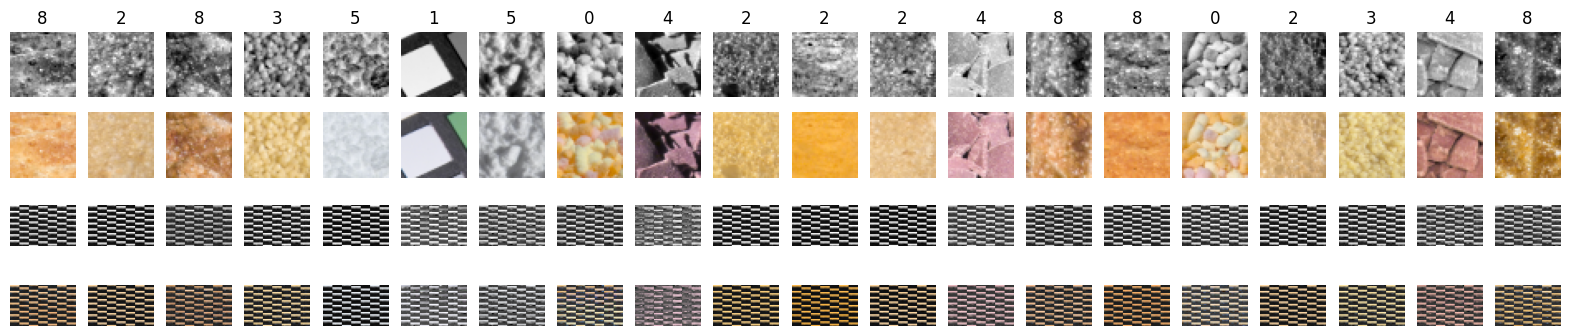

In [ ]:
def plot_feature_vectors(X_train, labels_train, feat_types, nsamples_to_show=20, random_state=50):
  # En primer lugar, mezclamos los vectores:
  X_shuffled, labels_shuffled = {}, {}
  for feat_type in feat_types:
    # Fijamos random_state a un número fijo cualquiera, para que todas las mezclas se realicen igual:
    X_shuffled[feat_type], labels_shuffled[feat_type] = shuffle(X_train[feat_type], labels_train, random_state=random_state)
  fig, axs, = plt.subplots(4, nsamples_to_show, figsize=(nsamples_to_show,4))
  for i, feat_type in enumerate(["gray","rgb","gabor_gray", "gabor_rgb"]):
    for j, (vec, lab) in enumerate(zip(X_shuffled[feat_type][:nsamples_to_show], labels_shuffled[feat_type][:nsamples_to_show])):
      if feat_type == "gray":
        axs[i,j].set_title(f"{lab}")
        axs[i,j].imshow(vec.reshape(TS,TS),cmap="gray")
      elif feat_type == "rgb":
        axs[i,j].imshow(vec.reshape(TS,TS,3))
      elif feat_type == "gabor_gray":
        axs[i,j].imshow(vec.reshape(7*len(GABOR_PARMS),7*GABOR_ORIENTATIONS), cmap="gray")
      elif feat_type == "gabor_rgb":
        img_gab_rgb = vec.reshape(7*len(GABOR_PARMS),7*GABOR_ORIENTATIONS,3)
        axs[i,j].imshow((img_gab_rgb-np.min(img_gab_rgb))/(np.max(img_gab_rgb)-np.min(img_gab_rgb)))
      axs[i,j].axis("off")

plot_feature_vectors(X_train, labels_train, feat_types, nsamples_to_show=20, random_state=50)

En realidad, las features de Gabor anteriores no se han visualizado demasiado intuitivamente. Para intentar presentar algo más intuitivo, mostraremos aquí los NKGABOR canales de salida (en este caso, sólo para el primer elemento de training de cada clase, y sólo para la salida de los filtros de Gabor de la imagen de grises). Obsérvense los efectos más aparentes de los promediados (capa average) y el filtro no lineal de máximo (capa max pool):

CPU times: user 3.33 s, sys: 9.1 ms, total: 3.34 s
Wall time: 3.36 s


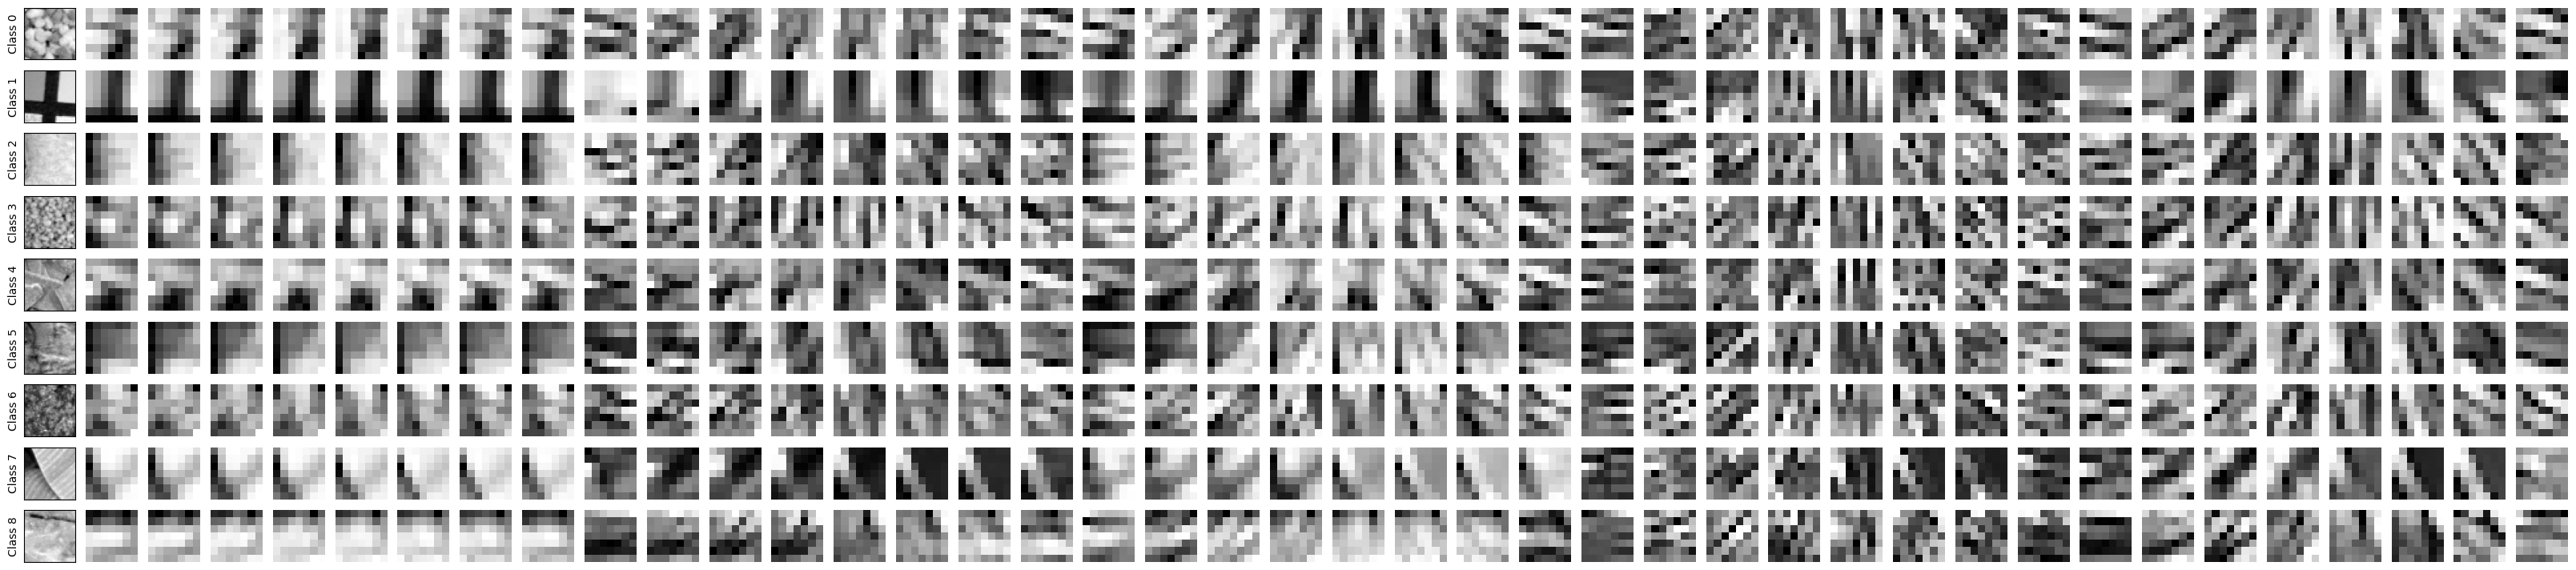

In [ ]:
%%time

def plot_gabor_gray_features(X_train, labels_train):
  fig, axs = plt.subplots(NC, NKGABOR+1, figsize=(NKGABOR+1, NC))
  for r in range(NC):
    ind = list(labels_train).index(r)
    axs[r,0].imshow(X_train["gray"][ind].reshape(TS,TS), cmap="gray")
    axs[r,0].set_xticks([])
    axs[r,0].set_yticks([])
    axs[r,0].set_ylabel(f"Class {r}")
    gab_result = X_train["gabor_gray"][ind].reshape(7,7,40)
    for c in range(NKGABOR):
      axs[r,c+1].imshow(gab_result[:,:,c], cmap="gray")
      axs[r,c+1].axis("off")

plot_gabor_gray_features(X_train, labels_train)

# Entrenamiento de un regresor logístico con sklearn

Entrenamos cuatro clasificadores sencillos (regresores logísticos multiclase de sklearn), con los cuatro datasets de _hand engineered features_:

In [ ]:
%%time

# Decorador python en realidad innecesario (es sólo para evitar algunos mensajes de warning no informativos)
@ignore_warnings(category=ConvergenceWarning)
def compute_sklearn_classifiers(feat_types):
  classifiers = {}
  for feat_type in feat_types:
    print(f"Computing classifier for {feat_type} features...", end="")
    classifiers[feat_type] = make_pipeline(StandardScaler(),  LogisticRegression(penalty="l2", solver="sag", max_iter=30)) # Alternativas: solver="lbfgs" | solver="liblinear",
    classifiers[feat_type].fit(X_train[feat_type], labels_train)
    print(" Done!")
  return classifiers

classifiers = compute_sklearn_classifiers(feat_types)
# print(classifiers)

Computing classifier for gray features... Done!
Computing classifier for rgb features... Done!
Computing classifier for gabor_gray features... Done!
Computing classifier for gabor_rgb features... Done!
CPU times: user 3min 28s, sys: 723 ms, total: 3min 28s
Wall time: 3min 30s


Y mostramos sus resultados tanto sobre el conjunto de training como sobre el de test:


                                                                                                           Results on training set
              precision    recall  f1-score   support                  precision    recall  f1-score   support                  precision    recall  f1-score   support                  precision    recall  f1-score   support
            
           0       0.64      0.63      0.63      1920               0       0.96      0.93      0.95      1920               0       0.86      0.85      0.85      1920               0       1.00      0.98      0.99      1920
           1       0.78      0.81      0.79      1920               1       0.97      0.98      0.98      1920               1       0.92      0.93      0.92      1920               1       0.99      0.99      0.99      1920
           2       0.63      0.61      0.62      1920               2       0.92      0.92      0.92      1920               2       0.68      0.77      0.72      1920             

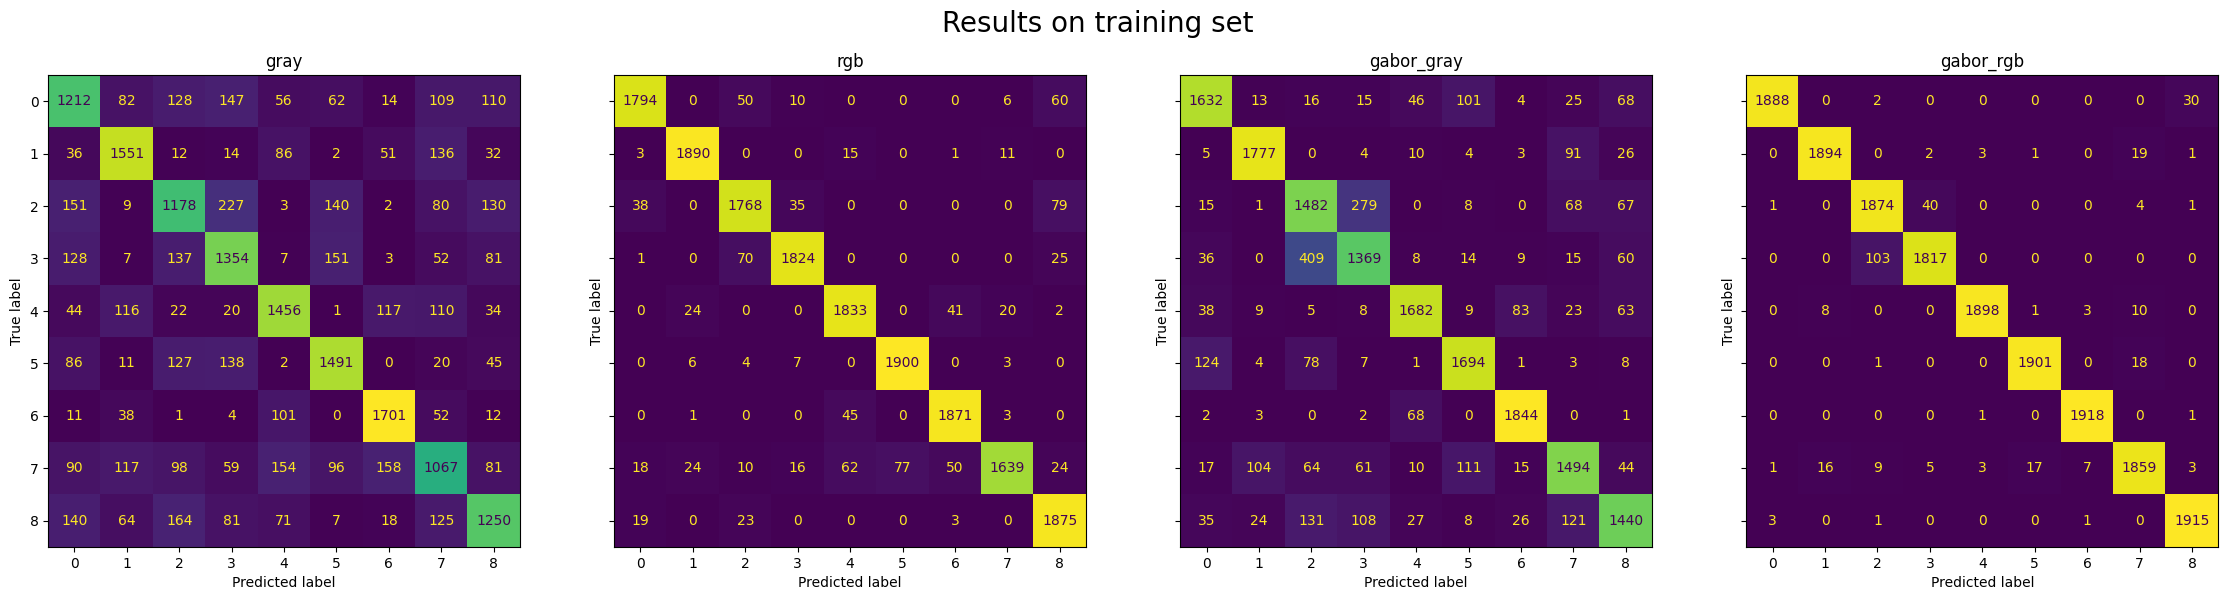

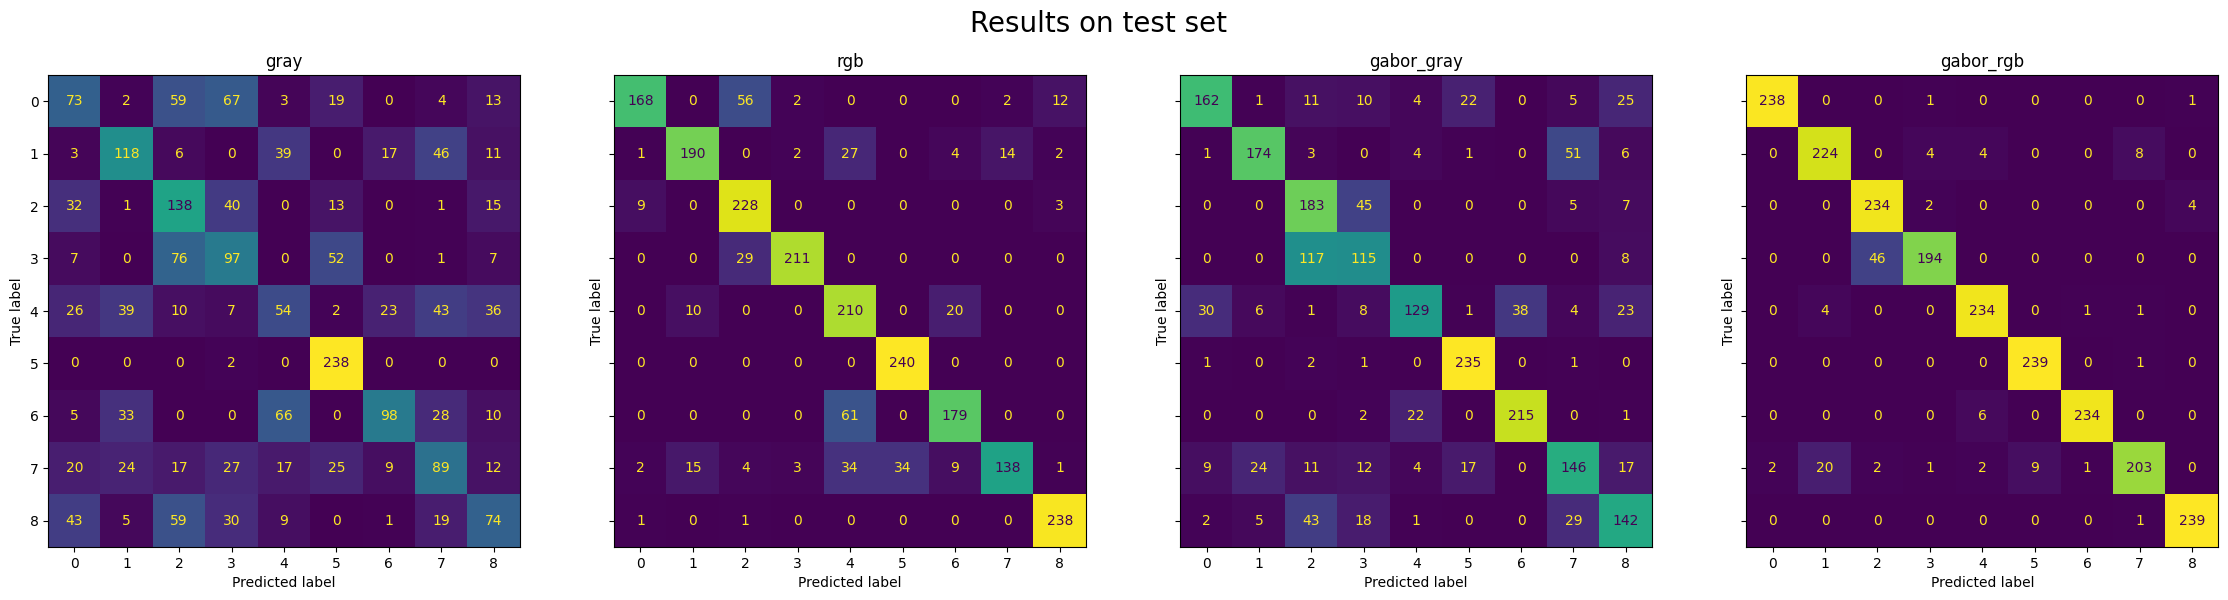

In [ ]:
def show_classifiers_results(feat_types, classifiers, X_train, X_test, labels_train, labels_test):
  # Usamos los clasificadores entrenados para predecir tanto en el conjunto de
  # train como en el de test:
  labels_train_pred, labels_test_pred = {}, {}
  for feat in feat_types:
    labels_train_pred[feat] = classifiers[feat].predict(X_train[feat])
    labels_test_pred[feat] = classifiers[feat].predict(X_test[feat])

  # Y mostramos los resultados (tanto el resumen de precision/recall por clase,
  # como la matriz de confusión, para ambos casos, training y test):
  for labels, labels_pred, title in zip([labels_train,labels_test], [labels_train_pred, labels_test_pred], ["Results on training set", "Results on test set"]):
    fig, axs = plt.subplots(1, len(feat_types), figsize=(28, 7), sharey='row')
    for i, feat in enumerate(feat_types):
      cf_matrix = confusion_matrix(labels, labels_pred[feat])
      disp = ConfusionMatrixDisplay(cf_matrix)
      disp.plot(ax=axs[i])
      disp.ax_.set_title(feat)
      disp.im_.colorbar.remove()
      fig.suptitle(title, fontsize=20, y=0.925)

    print(f"\n{title:>130}")
    print(f"{len(title)*'=':>130}")
    for i,line in enumerate(zip(*[classification_report(labels, labels_pred[feat]).split("\n") for feat in feat_types])):
      print(line[0] + "    " + line[1] + "    " + line[2] + "    " + line[3])

show_classifiers_results(feat_types, classifiers, X_train, X_test, labels_train, labels_test)

## Conclusiones del estudio de clasificadores _hand engineered_

Pueden extraerse varias conclusiones:
* Aunque los clasificadores ajustan relativamente bien los datos de training (85%-99% acierto, excepto el de grises, que sólo llega a un menor ~70%-75%), en realidad no todos están generalizando bien (los resultados empeoran bastante con los tests, especialmente en las versiones que trabajan con imágenes de gris, aunque en menor medida si se usan los filtros de Gabor).
* En general, a mayor número de _features_ extraídas, y a mayor sofisticación (Gabor mejor que vectores sacados de hacer un simple _"flatten"_ del parche), mejor rendimiento (medido ya sobre el conjunto de test): gabor_rgb > rgb > gabor_gray > gray.
* El mejor clasificador es, por tanto, gabor_rgb, con un rendimiento en test de alrededor del ~94%-96%.
* De las matrices de confusión se deduce fácilmente que las clases 2 y 3 son las que más confunden a los modelos aprendidos (lo cual tiene toda la lógica, ya que son las más parecidas visualmente entre sí).

**Nota**: Todos los porcentajes comentados pueden obviamente variar al cambiar las condiciones de tratamiento del dataset (tamaño del parche, stride, etc.), aunque, cualitativamente, salvo cambios drásticos en estos parámetros, se deberían seguir observando las tendencias comentadas.

# Segmentación de una imagen con una FCNN

**Nota:** Dadas las conclusiones obtenidas en el apartado anterior, a partir de este momento trabajaremos solamente usando el esquema de extracción de características más potente, esto es, el esquema `gabor_rgb`.

En este apartado vamos a construir una capa adicional que añadiremos al modelo de Keras que antes sólo realizaba la extracción de características (_backbone_) para que, añadiendo el classificador entrenado, realice una clasificación completa (esto es, decida, para cada parche de entrada, las probabilidades de que se trate de cualquiera de las 9 clases de textura).



Para ello, en primer lugar extraeremos los vectores de media y escalado del primer elemento del pipeline del clasificador sklearn (StandardScaler, que normaliza los vectores de entrada), y a continuación hacemos lo propio con los coeficientes y el bias del segundo elemento del pipeline (regresor logístico).



In [ ]:
mean = classifiers["gabor_rgb"]["standardscaler"].mean_
scale = classifiers["gabor_rgb"]["standardscaler"].scale_
coef = classifiers["gabor_rgb"]["logisticregression"].coef_
intercept = classifiers["gabor_rgb"]["logisticregression"].intercept_

# Imprimimos las formas de los valores extraídos:
print(f"mean vector:      {mean.shape}\n"
      f"scale vector:     {scale.shape}\n"
      f"coef vector:      {coef.shape}\n"
      f"intercept vector: {intercept.shape}")

# Comprobación de corrección:
assert mean.shape[-1] == scale.shape[-1] == coef.shape[-1] == NKGABORRGB *(((TS-2*(GABOR_SIZE//2))-1)//3)**2
assert coef.shape[0] == intercept.shape[0] == NC

mean vector:      (5880,)
scale vector:     (5880,)
coef vector:      (9, 5880)
intercept vector: (9,)


Adaptamos ahora los valores anteriores a la forma adecuada de los tensores para que encajen en la última capa (capa de clasificación) de nuestro nuevo modelo convolucional. Obsérvese que nuestra intención es, en este caso, hacer el modelo ya directamente _fully convolutional_ (esto es, que pueda realizarse la inferencia sobre imágenes completas de cualquier tamaño, no solamente parches de 40x40):

In [ ]:
# Hacemos los correspondientes "reshapes", para adaptarnos a la salida de la capa
# final del modelo anterior de extracción de características:
OUT_TENSOR_R = OUT_TENSOR_C = ((TS-2*(GABOR_SIZE//2))-1)//3
assert OUT_TENSOR_R == OUT_TENSOR_C == int(math.sqrt(len(mean)//NKGABORRGB))
mean_tensor = mean.reshape(OUT_TENSOR_R,OUT_TENSOR_C,NKGABORRGB,1)
scale_tensor = scale.reshape(OUT_TENSOR_R,OUT_TENSOR_C,NKGABORRGB,1)
coef_tensor = coef.reshape(9,OUT_TENSOR_R,OUT_TENSOR_C,NKGABORRGB)
coef_tensor = np.moveaxis(coef_tensor,[0,1,2,3],[3,0,1,2])
print(f"mean tensor:      {mean_tensor.shape}\n"
      f"scale tensor:     {scale_tensor.shape}\n"
      f"coef tensor:      {coef_tensor.shape}\n"
      f"intercept vector: {intercept.shape}")

mean tensor:      (7, 7, 120, 1)
scale tensor:     (7, 7, 120, 1)
coef tensor:      (7, 7, 120, 9)
intercept vector: (9,)


Transferimos ahora el efecto de la escala (scale_tensor) y la media (mean_tensor) de la primera etapa del pipeline de sklearn a los valores del clasificador de la segunda etapa (coef_tensor e intercept), para obtener ya simplemente dos tensores (coef_norm e intercept_norm) con los que construiremos la última capa del modelo:



In [ ]:
# Los pesos nuevos no son más que los pesos del clasificador convenientemente escalados por el factor de escalado
# de la entrada...
coef_norm = coef_tensor/scale_tensor
# ... si bien para los bias hay que hacer una pequeña cuenta, derivable si se hace el correspondiente desarrollo
# algebraico:
intercept_norm = -coef_tensor.reshape(-1,9).T @ (mean_tensor/scale_tensor).reshape(-1,1).flatten() + intercept
print(f"coef_norm tensor:      {coef_norm.shape}\n"
      f"intercept_norm vector: {intercept_norm.shape}")

coef_norm tensor:      (7, 7, 120, 9)
intercept_norm vector: (9,)


Finalmente, construimos con los pesos anteriores la capa final de clasificación, y con ella el nuevo modelo (que, recuérdese, es ya _fully convolutional_, y por tanto puede probarse con imágenes completas en lugar de con parches sueltos):

In [ ]:
def build_modelFCNN():
  layerClf = layers.Conv2D(NC, kernel_size=(OUT_TENSOR_R,OUT_TENSOR_C), strides=(1,1), padding='valid', use_bias=True, activation="softmax", name="classifier")
  layerClf.build((1,H,W,120))
  layerClf.set_weights([coef_norm, intercept_norm])

  layerGaborRGB = layers.Conv2D(kerneltensorrgb.shape[-1], kernel_size=(GABOR_SIZE,GABOR_SIZE), strides=(1,1), padding='valid', use_bias=False, name="GaborRGB")
  layerGaborRGB.build((1,TS,TS,3))
  layerGaborRGB.set_weights([kerneltensorrgb])

  return keras.Sequential([
      keras.Input(shape=(None, None, 3), name="Input"),
      layerGaborRGB,
      layers.AveragePooling2D(pool_size=(2, 2), strides=(1,1), padding="valid", name="Average"),
      layers.MaxPooling2D(pool_size=(3, 3), strides=(3,3), padding="valid", name="MaxPool"),
      layerClf,
    ], name="modelFCNN")

modelFCNN = build_modelFCNN()
modelFCNN.summary()

Model: "modelFCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ GaborRGB (Conv2D)               │ (None, None, None,     │       104,040 │
│                                 │ 120)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Average (AveragePooling2D)      │ (None, None, None,     │             0 │
│                                 │ 120)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool (MaxPooling2D)          │ (None, None, None,     │             0 │
│                                 │ 120)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Conv2D)             │ (None, None, None, 9)  │        52,929 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,969 (613.16 KB)

 Trainable params: 156,969 (613.16 KB)

 Non-trainable params: 0 (0.00 B)

El número de parámetros de la capa de clasificación final no es más que el resultado de multiplicar el tamaño del vector de entrada por el número de clases (matriz de pesos W de la capa) y sumar un _bias_ por cada clase, es decir:

5880*9+9=52929

He aquí también un esquema de la arquitectura de la red, modificada respecto a la básica, para obtener una versión _fully convolutional_, FCNN:

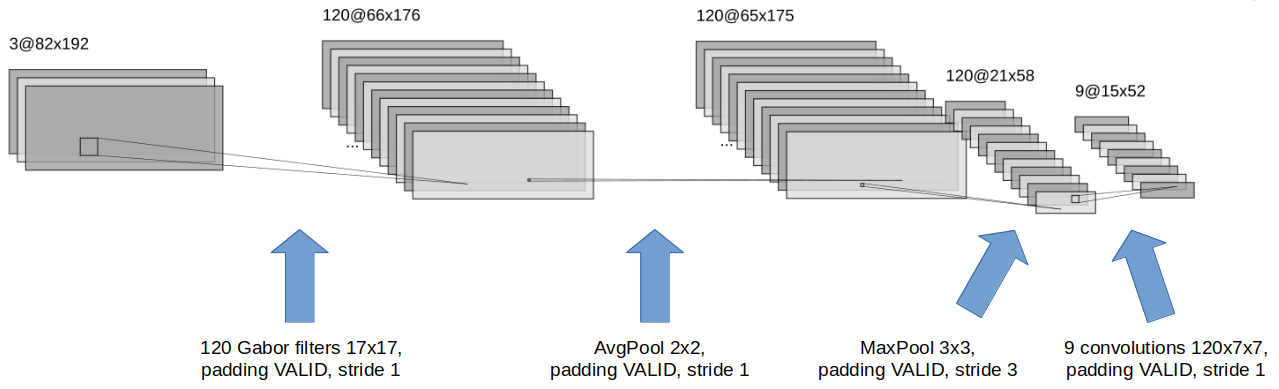

Construimos ahora una imagen para testear el modelo de segmentación construido:

(82, 1728, 3)


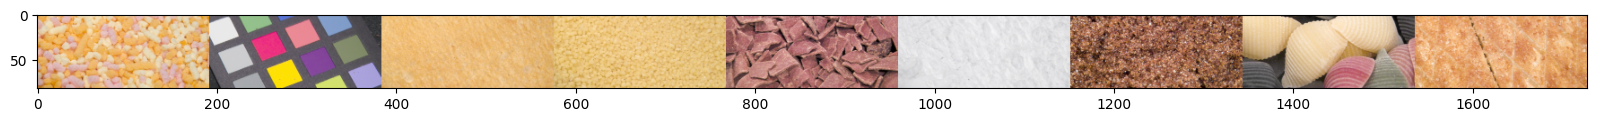

In [ ]:
def build_test_image_all_classes(ind_example):
  assert ind_example < NIS_TEST # Nos aseguramos de testear con imágenes no vistas durante el entrenamiento.
  imgtest = np.concatenate([imgsclass[-(ind_example+1)][:,:] for imgsclass in imgs],axis=1)
  return imgtest

imgtest = build_test_image_all_classes(2)
plt.figure(figsize=(20.0,NC*20.0))
plt.imshow(imgtest)
print(imgtest.shape)

Finalmente, probamos nuestro modelo FCNN con dicha imagen, dibujando, por cada canal de salida, una imagen de segmentación resultado. En condiciones ideales, las segmentaciones ideales deberían dibujar un resultado completamente diagonal, y las desviaciones frente a este muestran visualmente los casos de fallo:

Forma del tensor con el batch de entrada: (82, 1728, 3)
Forma del tensor con el batch de salida: (1, 15, 564, 9)



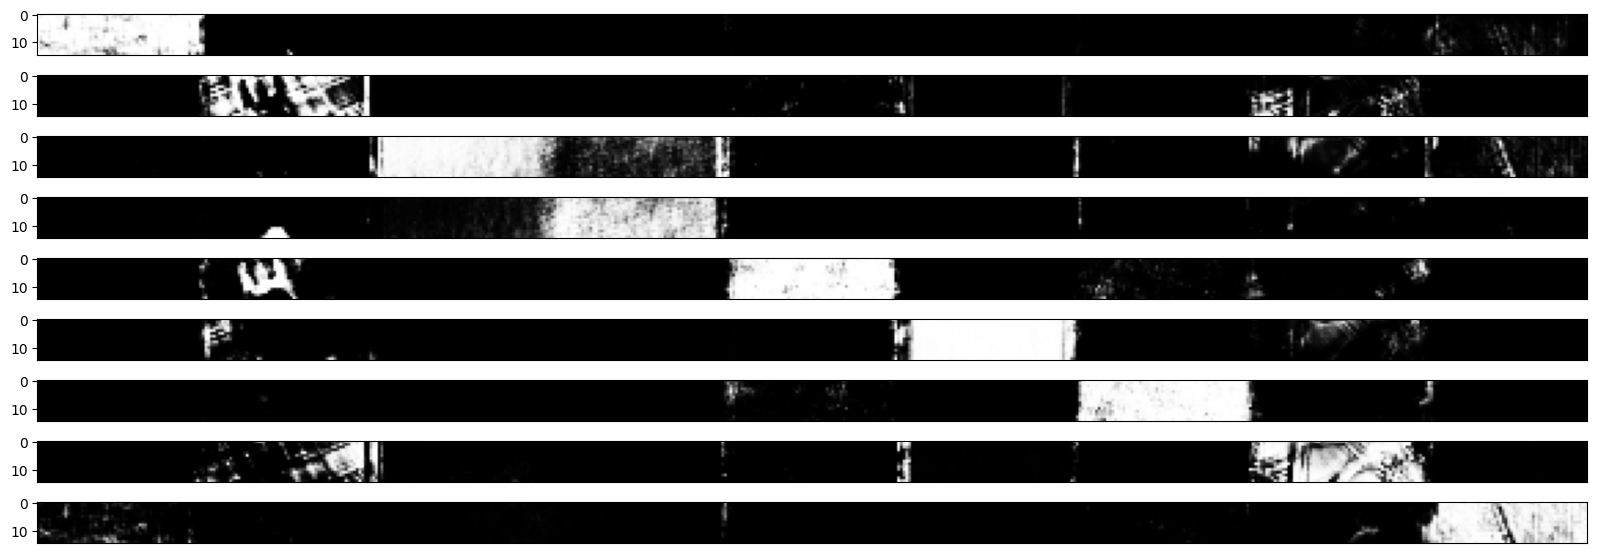

In [ ]:
input_batch = np.array([imgtest])
output_tensor = modelFCNN(input_batch)
print(f"Forma del tensor con el batch de entrada: {imgtest.shape}\n"
      f"Forma del tensor con el batch de salida: {output_tensor.shape}\n")
fig, axs = plt.subplots(NC, 1, figsize=(20.0,7.0))
for i in range(NC):
  axs[i].imshow(output_tensor[0,:,:,i], cmap="gray")
  axs[i].set_xticks([])

Comprobamos también ahora que, efectivamente, si aplicamos la red FCNN a una imagen de entrada, de dimensión 82x192, obtenemos un tensor de salida de 15x52x9, tal y como razonamos en el esquema de la red FCNN anterior:

Forma del tensor con el batch de entrada: (1, 82, 192, 3)
Forma del tensor con el batch de salida: (1, 15, 52, 9)



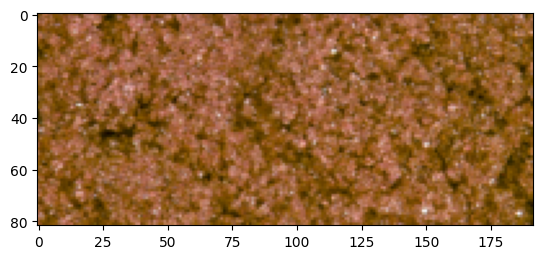

In [ ]:
single_img_test= imgs[6][0]
input_batch = np.array([single_img_test])
output_tensor = modelFCNN(input_batch)
print(f"Forma del tensor con el batch de entrada: {input_batch.shape}\n"
      f"Forma del tensor con el batch de salida: {output_tensor.shape}\n")
plt.imshow(single_img_test);

He aquí también dibujado, por _slices_, el correspondiente tensor de salida para dicha imagen (que, recordemos, se corresponde con una instancia de la clase 6):

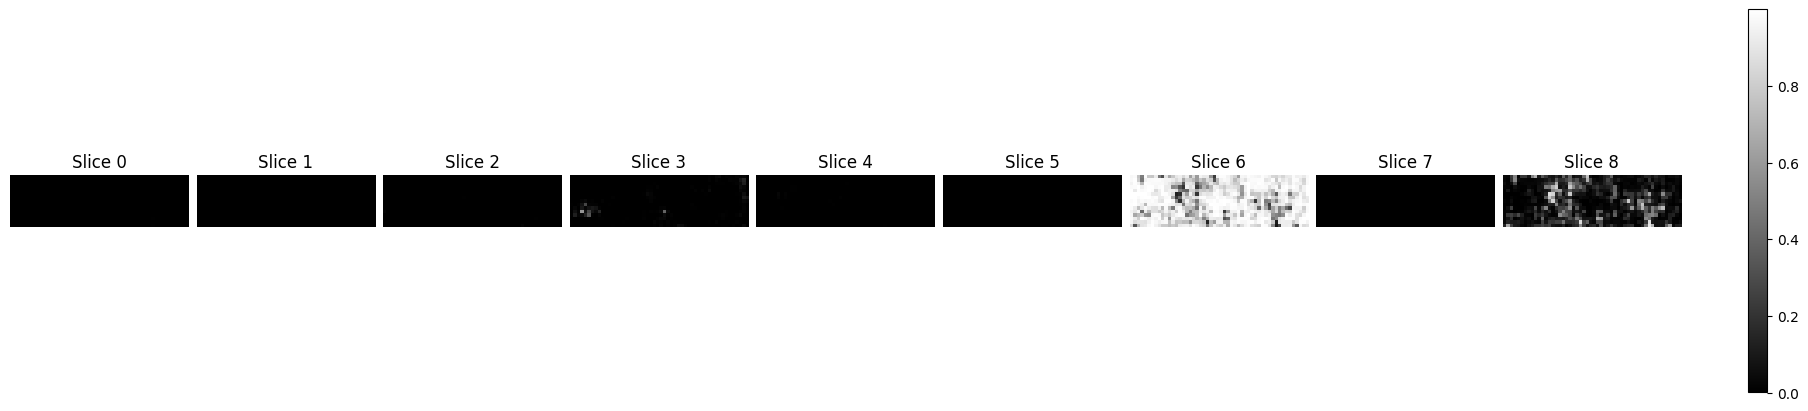

In [ ]:
# Crear la figura y los ejes
fig, axes = plt.subplots(1, 9, figsize=(18, 4), constrained_layout=True)

# Determinar el rango común para la barra de color
vmin, vmax = output_tensor.numpy().min(), output_tensor.numpy().max()

# Mostrar cada slice en escala de grises
for i in range(9):
    im = axes[i].imshow(output_tensor[0,:, :, i], cmap='gray', vmin=vmin, vmax=vmax)
    axes[i].set_title(f'Slice {i}')
    axes[i].axis('off')  # Ocultar los ejes

# Agregar una barra de color común
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

## Intento de mejorar vía gradiente descendente el modelo

Partimos ahora del modelo obtenido, con sus pesos iniciales, pero liberando sus parámetros y ejecutando una optimización vía gradiente descendente, a ver si logramos mejorarlo. En primer lugar, creamos un nuevo modelo con salida única (_flatten_), para evaluarlo entonces sobre el train, el test y la validación, donde deberíamos obtener unos valores similares a los obtenidos anteriormente con `sklearn`:

In [ ]:
%%time

# Creamos nuevo modelo (modelFCNNfree):
input_shape = (TS, TS, 3)
inputs = keras.layers.Input(shape=input_shape)
x = modelFCNN(inputs)
outputs = keras.layers.Flatten()(x)
modelFCNNfree = keras.models.Model(inputs=inputs, outputs=outputs)

# Imprimimos la forma de la salida (simple vector de 9 elementos = probabilidades de las clases):
print(modelFCNNfree(np.array([tiles_train[0]])).shape)

# Evaluamos el modelo ANTES de hacer un ajuste fino sobre él:
modelFCNNfree.set_weights(modelFCNN.get_weights())
modelFCNNfree.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.SGD(learning_rate=0.000001), metrics=["sparse_categorical_accuracy"])
print("Training evaluation:")
modelFCNNfree.evaluate(x=tiles_train,y=labels_train, batch_size=128)
print("Validation evaluation:")
modelFCNNfree.evaluate(x=tiles_val,y=labels_val, batch_size=128)
print("Test evaluation:")
modelFCNNfree.evaluate(x=tiles_test,y=labels_test, batch_size=128)

(1, 9)
Training evaluation:
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0943 - sparse_categorical_accuracy: 0.9793
Validation evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.2199 - sparse_categorical_accuracy: 0.9401
Test evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1604 - sparse_categorical_accuracy: 0.9539
CPU times: user 3.31 s, sys: 589 ms, total: 3.9 s
Wall time: 4.53 s


[0.18064089119434357, 0.9439814686775208]

Una vez comprobada la corrección del modelo, procedemos a ajustarlo (_fine-tuning_) entrenándolo partiendo de los pesos originales, y aplicando un gradiente descendiente con un _learning rate_ pequeño.

**Nota:** Si pensamos que usando un learning rate mayor podríamos mejorar los resultados, estamos equivocados; se puede comprobar que para _learning rate_ mayores no sólo no obtenemos mejores resultados, sino que incluso podemos hacer diverger al modelo.

In [ ]:
%%time

# Copiamos los pesos del modelo original...
modelFCNNfree.set_weights(modelFCNN.get_weights())
# ... decidimos qué capas queremos reentrenar ...
modelFCNNfree.get_layer("modelFCNN").get_layer('GaborRGB').trainable = True
modelFCNNfree.get_layer("modelFCNN").get_layer('classifier').trainable = True
# ... y finalmente reentrenamos (fine-tuning):
modelFCNNfree.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), metrics=["sparse_categorical_accuracy"])
history = modelFCNNfree.fit(x=tiles_train, y=labels_train, validation_data=(tiles_val,labels_val), batch_size=64, epochs=10)

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1074 - sparse_categorical_accuracy: 0.9749 - val_loss: 0.2603 - val_sparse_categorical_accuracy: 0.9176
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0985 - sparse_categorical_accuracy: 0.9799 - val_loss: 0.2305 - val_sparse_categorical_accuracy: 0.9306
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0985 - sparse_categorical_accuracy: 0.9792 - val_loss: 0.2343 - val_sparse_categorical_accuracy: 0.9245
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0956 - sparse_categorical_accuracy: 0.9793 - val_loss: 0.2406 - val_sparse_categorical_accuracy: 0.9250
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0971 - sparse_categorical_accuracy: 0.9784 - val_loss: 0.2227 - val_sparse_categorical_accuracy: 0.9366
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0968 - sparse_categorical_accuracy: 0.9802 - val_loss: 0.2431 - val_sparse_categorical_accuracy: 0.9255
Epo

Se comprueba que, tras unas cuantas épocas, el proceso no logra optimizar más los resultados: tanto la pérdida (_loss_) como la precisión (_accuracy_) se estancan desde el principio en el proceso de entrenamiento.

Ahora evaluamos el modelo ajustado, comprobando que no se mejoran los resultados; el modelo carece de la profundidad necesaria para generar mejores características intermedias, y parece tener un tope de rendimiento en validación de alrededor de, como mucho, 94%-95%:

In [ ]:
%%time

modelFCNNfree.evaluate(x=tiles_train,y=labels_train, batch_size=64)
modelFCNNfree.evaluate(x=tiles_val,y=labels_val, batch_size=64)
modelFCNNfree.evaluate(x=tiles_test,y=labels_test, batch_size=64)

270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0860 - sparse_categorical_accuracy: 0.9816
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2331 - sparse_categorical_accuracy: 0.9375
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1675 - sparse_categorical_accuracy: 0.9394
CPU times: user 1.55 s, sys: 545 ms, total: 2.09 s
Wall time: 2.27 s


[0.17604130506515503, 0.9347222447395325]

Comparemos visualmente los pesos originales con los modificados por el proceso de aprendizaje. Vemos que, aunque ciertamente dicho proceso ha modificado apreciablemente muchos de esos pesos, no ha logrado mejorar los resultados, debido fundamentalmente a la falta de profundidad de la red.

**Nota:** En realidad, por simplicidad, mostramos aquí sólo uno de los tres canales RGB, para comparar directamente con los filtros de Gabor monocanal.

Pesos antes del aprendizaje:


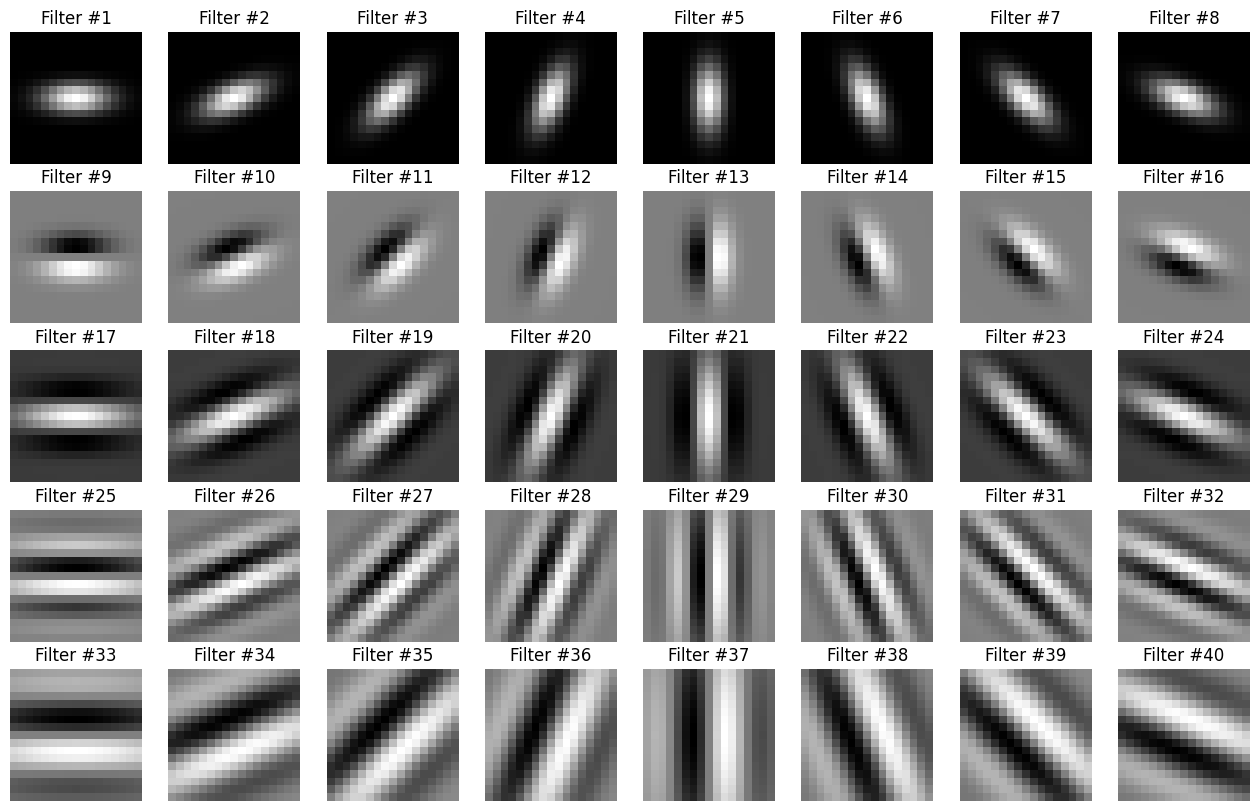

In [ ]:
plot_filters(kerneltensorgray)
print("Pesos antes del aprendizaje:")

Pesos tras el aprendizaje:


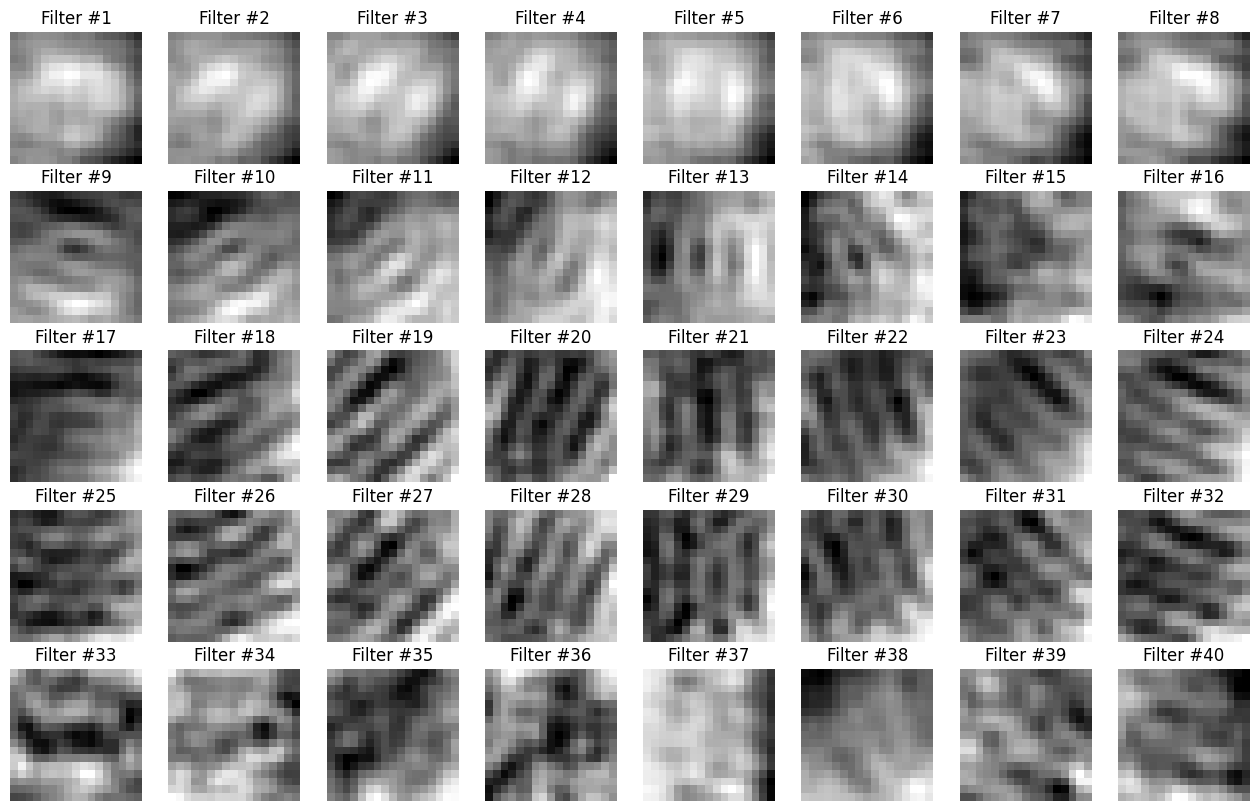

In [ ]:
freeweights1stlayer = modelFCNNfree.get_weights()[0]
plot_filters(freeweights1stlayer[:,:,2,::3][:,:,np.newaxis,:])
print("Pesos tras el aprendizaje:")

# Alternativa CNN desde cero

Definimos un primer modelo convolucional de clasificación sencillo, con dos capas convolucionales, seguidas de un _"flatten"_ (por lo que la red no será completamente convolucional -esto es, _fully convolutional_, o FC-) y la correspondiente capa densa de salida, con activación _softmax_ para decidir entre las 9 clases:

In [ ]:
num_classes = NC
input_shape = (TS, TS, 3)
newmodel = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(5, 5), activation="relu", padding="valid"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="valid"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

newmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 36, 36, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        36,873 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,801 (225.79 KB)

 Trainable params: 57,801 (225.79 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamos el modelo y observamos que puede alcanzar un rendimiento de 98~99%, confiando en los pesos hallados por el gradiente descendente, sin haber tenido que "pensar" más que una arquitectura CNN convencional, muy similar a las utilizadas para problemas como [MNIST](https://es.wikipedia.org/wiki/Base_de_datos_MNIST):

In [ ]:
%%time

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

# Definimos el callback para guardar el mejor modelo según la métrica sobre el conjunto de validación:
checkpoint_callback = ModelCheckpoint("best_model.keras", monitor="val_sparse_categorical_accuracy", save_best_only=True, mode="max",verbose=1)

newmodel.compile(loss="sparse_categorical_crossentropy",optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),metrics=["sparse_categorical_accuracy"])
history = newmodel.fit(x=tiles_train,y=labels_train,validation_data=(tiles_val, labels_val),batch_size=64,epochs=30,callbacks=[checkpoint_callback])

# Recarga el mejor modelo guardado correspondiente a la mejor iteración
newmodel = load_model("best_model.keras")


Epoch 1/30
263/270 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9659 - sparse_categorical_accuracy: 0.2641
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.71528, saving model to best_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.9562 - sparse_categorical_accuracy: 0.2682 - val_loss: 1.0182 - val_sparse_categorical_accuracy: 0.7153
Epoch 2/30
266/270 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9987 - sparse_categorical_accuracy: 0.6314
Epoch 2: val_sparse_categorical_accuracy improved from 0.71528 to 0.78287, saving model to best_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9974 - sparse_categorical_accuracy: 0.6318 - val_loss: 0.6973 - val_sparse_categorical_accuracy: 0.7829
Epoch 3/30
265/270 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7714 - sparse_categorical_accuracy: 0.7025
Epoch 3: val_sparse_categorical_accuracy improved from 0.78287 to 0.85926, saving model to best_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.77

Dibujamos ahora las curvas de aprendizaje:

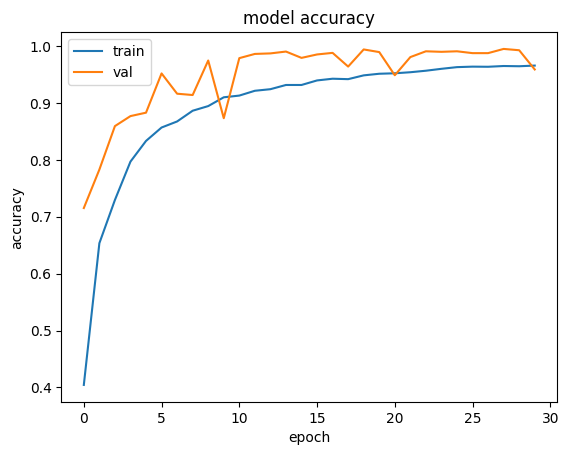

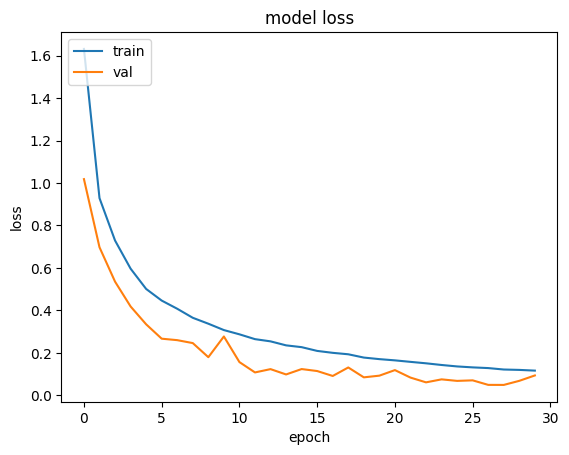

In [ ]:
# Resumen de la historia del aprendizaje para la precisión final (accuracy):
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# Resumen de la historia del aprendizaje para la función de pérdida (loss):
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Comprobamos los resultados del nuevo modelo, bastante mejores que los obtenidos con los modelos _hand engineered_ (~99% en validación, y un valor similar en el conjunto de test).

In [ ]:
%%time

newmodel.evaluate(x=tiles_train,y=labels_train, batch_size=128)
newmodel.evaluate(x=tiles_val,y=labels_val, batch_size=128)
newmodel.evaluate(x=tiles_test,y=labels_test, batch_size=128)

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0978 - sparse_categorical_accuracy: 0.9716
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0419 - sparse_categorical_accuracy: 0.9973
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0547 - sparse_categorical_accuracy: 0.9928 
CPU times: user 2.47 s, sys: 551 ms, total: 3.02 s
Wall time: 3.06 s


[0.05499754101037979, 0.9935185313224792]

## Conversión del modelo de clasificación anterior a una FCNN



Convertimos el modelo anterior para hacerlo completamente convolucional (FC):

In [ ]:
num_classes = NC
input_shape = (None, None, 3)

newmodelFCC = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(5, 5), activation="relu", padding="valid"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="valid"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.5),
        layers.Conv2D(9, kernel_size=(8, 8), activation="softmax", padding="valid"),
    ]
)

newmodelFCC.summary()

print(newmodelFCC(np.array([tiles_train[0]])).shape)

# Copia de pesos del anterior modelo CNN no FC al nuevo modelo FC:
weights = newmodel.get_weights()
weights[-2] = weights[-2].reshape(8,8,64,9)
newmodelFCC.set_weights(weights)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, None, None, 32) │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, None, None, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, None, None, 64) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, None, None, 9)  │        36,873 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,801 (225.79 KB)

 Trainable params: 57,801 (225.79 KB)

 Non-trainable params: 0 (0.00 B)

(1, 1, 1, 9)


Finalmente, probamos con imagen completa de prueba que incluye las nueve clases, y comprobamos visualmente el mejor comportamiento de esta última red:

Forma del tensor con el batch de entrada: (82, 1728, 3)
Forma del tensor con el batch de salida: (1, 11, 423, 9)



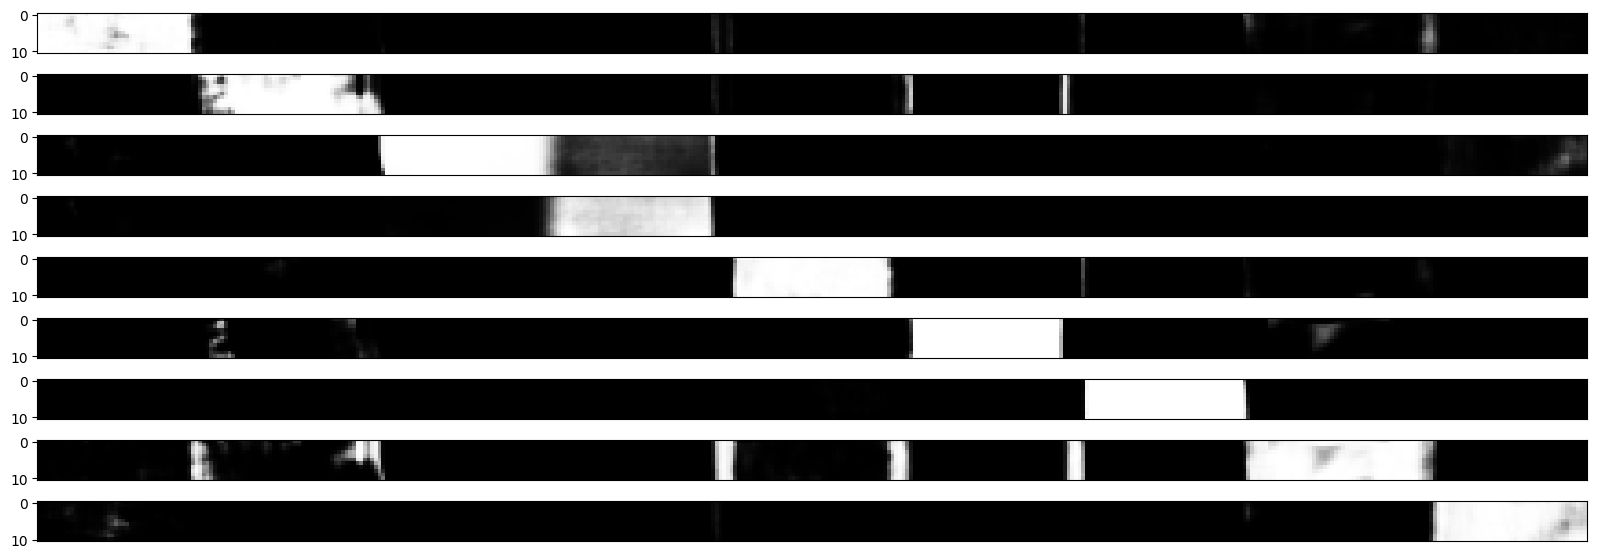

In [ ]:
input_batch = np.array([imgtest])
output_tensor = newmodelFCC(input_batch)
print(f"Forma del tensor con el batch de entrada: {imgtest.shape}\n"
      f"Forma del tensor con el batch de salida: {output_tensor.shape}\n")  # Lógicamente, ligeramente diferente al de la anterior FCNN por el cambio de arquitectura.
fig, axs = plt.subplots(NC, 1, figsize=(20.0,7.0))
for i in range(NC):
  axs[i].imshow(output_tensor[0,:,:,i], cmap="gray")
  axs[i].set_xticks([])

Se observa que los resultados mejoran de forma apreciable, con la diagonal principal bastante más marcada que en el caso del modelo "diseñado manualmente".

## Aspecto de los nuevos pesos de la primera capa

Sólo por curiosidad, vamos a estudiar los pesos obtenidos por la red para los pesos de la capa de entrada: observamos que, en este caso, ni siquiera parecen tener un significado geométrico claro, probablemente como corresponde a la variedad de nuestras texturas de entrada. En redes CNN más realistas, entrenadas con millones de imágenes reales, en estas primeras capas, por el contrario, suelen aparecer pesos formando algo así como pequeños detectores de bordes, esquinas, blobs, etc.

(5, 5, 96)


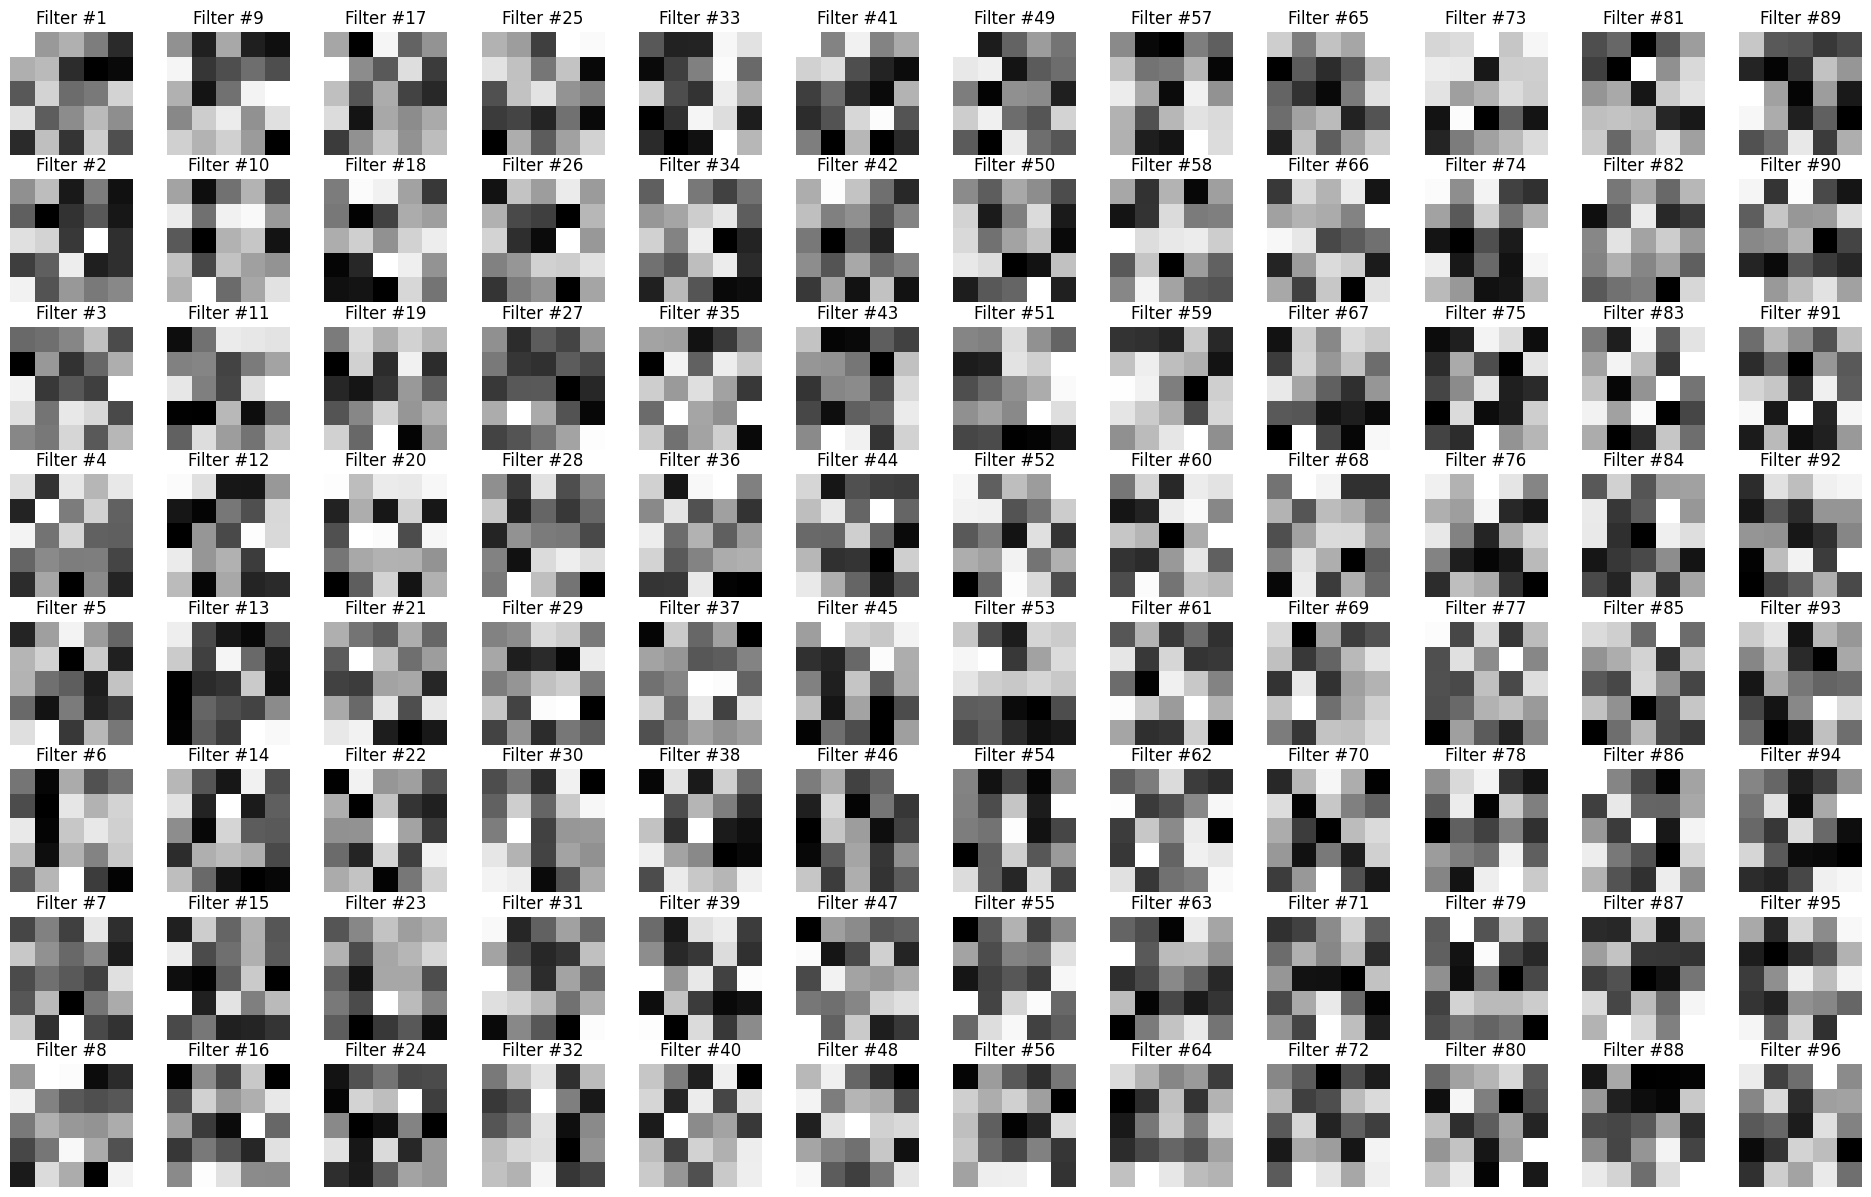

In [ ]:
# weights[0].shape # (5, 5, 3, 32)
newfilters = weights[0].reshape(5,5,-1)
print(newfilters.shape)

def plot_new_filters(weights):
  fig, axs = plt.subplots(8, 12, figsize=(24.0,15.0))
  for i in range(96):
    axs[i%8,i//8].imshow(weights[:,:,i], cmap="gray")
    axs[i%8,i//8].axis("off")
    axs[i%8,i//8].set_title(f"Filter #{i+1}")

plot_new_filters(newfilters)

In [ ]:
!date

Thu Nov 13 09:30:28 AM UTC 2025
